In [2]:
from typing import (List,Tuple,Dict,Callable,Union)

import datetime as dt
import numpy as np
import pandas as pd
import empyrical as ep

import graphviz
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestClassifier

from tqdm import tqdm_notebook

import alphalens as al

from jqdata import *
from jqfactor import (calc_factors,Factor)

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

In [3]:
'''股票池筛选'''
# 获取年末季末时点
def get_trade_period(start_date: str, end_date: str, freq: str = 'ME') -> list:
    '''
    start_date/end_date:str YYYY-MM-DD
    freq:M月，Q季,Y年 默认ME E代表期末 S代表期初
    ================
    return  list[datetime.date]
    '''
    days = pd.Index(pd.to_datetime(get_trade_days(start_date, end_date)))
    idx_df = days.to_frame()

    if freq[-1] == 'E':
        day_range = idx_df.resample(freq[0]).last()
    else:
        day_range = idx_df.resample(freq[0]).first()

    day_range = day_range[0].dt.date

    return day_range.dropna().values.tolist()


# 筛选股票池
class Filter_Stocks(object):
    '''
    获取某日的成分股股票
    1. 过滤st
    2. 过滤上市不足N个月
    3. 过滤当月交易不超过N日的股票
    ---------------
    输入参数：
        index_symbol:指数代码,A等于全市场,
        watch_date:日期
    '''
    
    def __init__(self,symbol:str,watch_date:str)->None:
        
        if isinstance(watch_date,str):
            
            self.watch_date = pd.to_datetime(watch_date).date()
            
        else:
            
            self.watch_date = watch_date
            
        self.symbol = symbol
        self.get_index_component_stocks()
        
    def get_index_component_stocks(self)->list:
        
        '''获取指数成分股'''
        
        if self.symbol == 'A':
            
            wd:pd.DataFrame = get_all_securities(types=['stock'],date=self.watch_date)
            self.securities:List = wd.query('end_date != "2200-01-01"').index.tolist()
        else:
            
            self.securities:List = get_index_stocks(self.symbol,self.watch_date)
    
    def filter_paused(self,paused_N:int=1,threshold:int=None)->list:
        
        '''过滤停牌股
        -----
        输入:
            paused_N:默认为1即查询当日不停牌
            threshold:在过paused_N日内停牌数量小于threshold
        '''
        
        if (threshold is not None) and (threshold > paused_N):
            raise ValueError(f'参数threshold天数不能大于paused_N天数')
            
        
        paused = get_price(self.securities,end_date=self.watch_date,count=paused_N,fields='paused',panel=False)
        paused = paused.pivot(index='time',columns='code')['paused']
        
        # 如果threhold不为None 获取过去paused_N内停牌数少于threshodl天数的股票
        if threshold:
            
            sum_paused_day = paused.sum()
            self.securities = sum_paused_day[sum_paused_day < threshold].index.tolist()
        
        else:
            
            paused_ser = paused.iloc[-1]
            self.securities = paused_ser[paused_ser == 0].index.tolist()

    def filter_zdt(self)->list:
        
        '''过滤zdt股
        0是满足非涨跌，非停板
        '''
        zdt = get_price(self.securities,end_date=self.watch_date,fields=['close','high_limit','low_limit','paused'],count=1,panel=False,fq='post')
        zdt['zdt_raw'] = zdt.apply(lambda x :1 if ((x['close']==x['high_limit']) or (x['close']==x['low_limit'])) else 0, axis = 1)
        zdt['zdt'] = zdt.apply(lambda x: 0 if ((x['paused']==0) and (x['zdt_raw']==0)) else 1, axis = 1)
        
        zdt = zdt.pivot(index='time',columns='code')['zdt']
        zdt_ser = zdt.iloc[-1]
        self.securities = zdt_ser[zdt_ser == 0].index.tolist()
    
    def filter_st(self)->list:
        
        '''过滤ST'''
              
        extras_ser = get_extras('is_st',self.securities,end_date=self.watch_date,count=1).iloc[-1]
        
        self.securities = extras_ser[extras_ser == False].index.tolist()
    
    def filter_ipodate(self,threshold:int=180)->list:
        
        '''
        过滤上市天数不足以threshold天的股票
        -----
        输入：
            threhold:默认为180日
        '''
        
        def _check_ipodate(code:str,watch_date:dt.date)->bool:
            
            code_info = get_security_info(code)
            
            if (code_info is not None) and ((watch_date - code_info.start_date).days > threshold):
                
                return True
            
            else:
                
                return False

        self.securities = [code for code in self.securities if _check_ipodate(code,self.watch_date)]
    
    
    
    def filter_industry(self,industry:Union[List,str],level:str='sw_l1',method:str='industry_name')->list:
        '''过略行业'''
        ind = get_stock_ind(self.securities,self.watch_date,level,method)
        target = ind.to_frame('industry').query('industry != @industry')
        self.securities = target.index.tolist()
        
def get_stock_ind(securities:list,watch_date:str,level:str='sw_l1',method:str='industry_code')->pd.Series:
    
    '''
    获取行业
    --------
        securities:股票列表
        watch_date:查询日期
        level:查询股票所属行业级别
        method:返回行业名称or代码
    '''
    
    indusrty_dict = get_industry(securities, watch_date)

    indusrty_ser = pd.Series({k: v.get(level, {method: np.nan})[
                             method] for k, v in indusrty_dict.items()})
    
    indusrty_ser.name = method.upper()
    
    return indusrty_ser

'''风险指标'''
# 风险指标


def Strategy_performance(return_df: pd.DataFrame,
                         periods='daily') -> pd.DataFrame:
    '''计算风险指标 默认为月度:月度调仓'''

    ser: pd.DataFrame = pd.DataFrame()
    ser['年化收益率'] = ep.annual_return(return_df, period=periods)
    ser['累计收益'] = ep.cum_returns(return_df).iloc[-1]
    ser['波动率'] = return_df.apply(
        lambda x: ep.annual_volatility(x, period=periods))
    ser['夏普'] = return_df.apply(ep.sharpe_ratio, period=periods)
    ser['最大回撤'] = return_df.apply(lambda x: ep.max_drawdown(x))
    
    if 'benchmark' in return_df.columns:

        select_col = [col for col in return_df.columns if col != 'benchmark']

        ser['IR'] = return_df[select_col].apply(
            lambda x: information_ratio(x, return_df['benchmark']))
        ser['Alpha'] = return_df[select_col].apply(
            lambda x: ep.alpha(x, return_df['benchmark'], period=periods))
        
        ser['超额收益'] = ser['年化收益率'] - ser.loc[
            'benchmark', '年化收益率']  #计算相对年化波动率
        
    return ser.T


def information_ratio(returns, factor_returns):
    """
    Determines the Information ratio of a strategy.

    Parameters
    ----------
    returns : :py:class:`pandas.Series` or pd.DataFrame
        Daily returns of the strategy, noncumulative.
        See full explanation in :func:`~empyrical.stats.cum_returns`.
    factor_returns: :class:`float` / :py:class:`pandas.Series`
        Benchmark return to compare returns against.

    Returns
    -------
    :class:`float`
        The information ratio.

    Note
    -----
    See https://en.wikipedia.org/wiki/information_ratio for more details.

    """
    if len(returns) < 2:
        return np.nan

    active_return = _adjust_returns(returns, factor_returns)
    tracking_error = np.std(active_return, ddof=1)
    if np.isnan(tracking_error):
        return 0.0
    if tracking_error == 0:
        return np.nan
    return np.mean(active_return) / tracking_error


def _adjust_returns(returns, adjustment_factor):
    """
    Returns a new :py:class:`pandas.Series` adjusted by adjustment_factor.
    Optimizes for the case of adjustment_factor being 0.

    Parameters
    ----------
    returns : :py:class:`pandas.Series`
    adjustment_factor : :py:class:`pandas.Series` / :class:`float`

    Returns
    -------
    :py:class:`pandas.Series`
    """
    if isinstance(adjustment_factor, (float, int)) and adjustment_factor == 0:
        return returns.copy()
    return returns - adjustment_factor

In [5]:
# 标记得分
def sign(ser: pd.Series) -> pd.Series:
    '''标记分数,正数为1,负数为0'''
    
    return ser.apply(lambda x: np.where(x > 0, 1, 0))

class FScore(Factor):
    '''
    FScore原始模型
    '''
    name = 'FScore'
    max_window = 1

    watch_date = None
    # paidin_capital 实收资本 股本变化会反应在该科目中
    dependencies = [
        'roa', 'roa_4', 'net_operate_cash_flow', 'total_assets',
        'total_assets_1', 'total_assets_4', 'total_assets_5',
        'operating_revenue', 'operating_revenue_4',
        'total_non_current_assets', 'total_non_current_liability',
        'total_non_current_assets_4', 'total_non_current_liability_4',
        'total_current_assets', 'total_current_liability',
        'total_current_assets_4', 'total_current_liability_4',
        'gross_profit_margin', 'gross_profit_margin_4', 'paidin_capital',
        'paidin_capital_4'
    ]

    def calc(self, data: Dict) -> None:

        roa: pd.DataFrame = data['roa'] # 单位为百分号

        cfo: pd.DataFrame = data['net_operate_cash_flow'] / \
            data['total_assets']

        delta_roa: pd.DataFrame = roa / data['roa_4'] - 1

        accrual: pd.DataFrame = cfo - roa * 0.01

        # 杠杆变化
        ## 变化为负数时为1，否则为0 取相反
        leveler: pd.DataFrame = data['total_non_current_liability'] / \
            data['total_non_current_assets']

        leveler1: pd.DataFrame = data['total_non_current_liability_4'] / \
            data['total_non_current_assets_4']

        delta_leveler: pd.DataFrame = -(leveler / leveler1 - 1)

        # 流动性变化
        liquid: pd.DataFrame = data['total_current_assets'] / \
            data['total_current_liability']

        liquid_1: pd.DataFrame = data['total_current_assets_4'] / \
            data['total_current_liability_4']

        delta_liquid: pd.DataFrame = liquid / liquid_1 - 1

        # 毛利率变化
        delta_margin: pd.DataFrame = data['gross_profit_margin'] / \
            data['gross_profit_margin_4'] - 1

        # 是否发行普通股权
        eq_offser: pd.DataFrame = -(data['paidin_capital'] / data[
            'paidin_capital_4'] - 1)

        # 总资产周转率
        total_asset_turnover_rate: pd.DataFrame = data[
            'operating_revenue'] / (data['total_assets'] +
                                          data['total_assets_1']).mean()

        total_asset_turnover_rate_1: pd.DataFrame = data[
            'operating_revenue_4'] / (data['total_assets_4'] +
                                            data['total_assets_5']).mean()

        # 总资产周转率同比
        delta_turn: pd.DataFrame = total_asset_turnover_rate / \
            total_asset_turnover_rate_1 - 1

        indicator_tuple: Tuple = (roa, cfo, delta_roa, accrual, delta_leveler,
                                  delta_liquid, delta_margin, delta_turn,
                                  eq_offser)

        # 储存计算FFscore所需原始数据
        self.basic: pd.DataFrame = pd.concat(indicator_tuple).T.replace([-np.inf,np.inf],np.nan)

        self.basic.columns = [
            'ROA', 'CFO', 'DELTA_ROA', 'ACCRUAL', 'DELTA_LEVELER',
            'DLTA_LIQUID', 'DELTA_MARGIN', 'DELTA_TURN', 'EQ_OFFSER'
        ]
        
        self.fscore: pd.Series = self.basic.apply(sign).sum(axis=1)

In [6]:
# 因子获取
def get_FFScore(
    symbol: str,
    factor: Factor,
    periods: List,
    filter_industry: Union[List,
                           str] = None) -> Tuple[pd.Series, pd.DataFrame]:
    '''
    获取FFScore得分
    ------
    输入参数：
        symbol:输入A表示全A股票池或者输入指数代码
        factor:不同的ffscore模型
        periods:计算得分的时间序列
        filter_industry:传入需要过滤的行业
    ------
    return 最终得分,财务数据
    '''
    for trade in tqdm_notebook(periods, desc='FFScore因子获取'):

        # 获取股票池
        stock_pool_func = Filter_Stocks(symbol, trade)
        stock_pool_func.filter_zdt()
        stock_pool_func.filter_paused(22, 21)  # 过滤22日停牌超过21日的股票
        stock_pool_func.filter_st()  # 过滤st
        stock_pool_func.filter_ipodate(180)  # 过滤次新
        # 是否过滤行业
        if filter_industry:

            stock_pool_func.filter_industry(filter_industry)

        my_factor = factor()
        my_factor.watch_date = trade
        calc_factors(stock_pool_func.securities,[my_factor],start_date=trade,end_date=trade)
        
        yield my_factor

In [7]:
def quantile_trans(df, tau):
    df_trans = df.apply(lambda x: -1 * (x - x.quantile(tau))**2, axis=1)
    return df_trans

def get_factor_price(security: Union[List, str],
                     periods: List) -> pd.DataFrame:
    '''获取对应频率的收盘价'''
    for trade in tqdm_notebook(periods, desc='获取收盘价数据'):

        yield get_price(security,
                        end_date=trade,
                        count=1,
                        fields='close',
                        fq = 'post',
                        panel=False)


def get_factor_pb_ratio(securities: Union[list, str],
                        periods: list) -> pd.DataFrame:
    '''获取PB数据'''
    for trade in tqdm_notebook(periods, desc='获取PB数据'):

        yield get_valuation(securities,
                            end_date=trade,
                            fields=['pb_ratio'],
                            count=1)

def get_factor_pe_ratio(securities: Union[list, str],
                        periods: list) -> pd.DataFrame:
    '''获取PE数据'''
    for trade in tqdm_notebook(periods, desc='获取PE数据'):

        yield get_valuation(securities,
                            end_date=trade,
                            fields=['pe_ratio'],
                            count=1)        
        
def get_factor_ps_ratio(securities: Union[list, str],
                        periods: list) -> pd.DataFrame:
    '''获取PS数据'''
    for trade in tqdm_notebook(periods, desc='获取PS数据'):

        yield get_valuation(securities,
                            end_date=trade,
                            fields=['ps_ratio'],
                            count=1) 
        
def get_factor_pcf_ratio(securities: Union[list, str],
                        periods: list) -> pd.DataFrame:
    '''获取PCF数据'''
    for trade in tqdm_notebook(periods, desc='获取PCF数据'):

        yield get_valuation(securities,
                            end_date=trade,
                            fields=['pcf_ratio'],
                            count=1)         

        
def get_DP(security,watch_date,days):
    
    # 获取股息数据
    one_year_ago=watch_date-datetime.timedelta(days=days)
    
    q1=query(finance.STK_XR_XD.a_registration_date,finance.STK_XR_XD.bonus_amount_rmb,\
            finance.STK_XR_XD.code\
           ).filter(finance.STK_XR_XD.a_registration_date>= one_year_ago,\
                    finance.STK_XR_XD.a_registration_date<=watch_date,\
                    finance.STK_XR_XD.code.in_(security[0:int(len(security)*0.3)]))
    q2=query(finance.STK_XR_XD.a_registration_date,finance.STK_XR_XD.bonus_amount_rmb,\
            finance.STK_XR_XD.code\
           ).filter(finance.STK_XR_XD.a_registration_date>= one_year_ago,\
                    finance.STK_XR_XD.a_registration_date<=watch_date,\
                    finance.STK_XR_XD.code.in_(security[int(len(security)*0.3):int(len(security)*0.6)]))
    q3=query(finance.STK_XR_XD.a_registration_date,finance.STK_XR_XD.bonus_amount_rmb,\
            finance.STK_XR_XD.code\
           ).filter(finance.STK_XR_XD.a_registration_date>= one_year_ago,\
                    finance.STK_XR_XD.a_registration_date<=watch_date,\
                    finance.STK_XR_XD.code.in_(security[int(len(security)*0.6):]))
    
    
    df_data1=finance.run_query(q1)
    df_data2=finance.run_query(q2)
    df_data3=finance.run_query(q3)
    df_data=pd.concat([df_data1,df_data2,df_data3],axis=0,sort=False)
    df_data.fillna(0,inplace=True)
    
    df_data=df_data.set_index('code')
    df_data=df_data.groupby('code').sum()
    
    #获取市值相关数据
    q01=query(valuation.code,valuation.market_cap).filter(valuation.code.in_(security))
    BP_data=get_fundamentals(q01,date=watch_date)
    BP_data=BP_data.set_index('code')
    
    #合并数据
    data=pd.concat([df_data,BP_data],axis=1,sort=False)
    data.fillna(0,inplace=True)
    data['dp']=(data['bonus_amount_rmb']/10000)/data['market_cap']
#     data1=data.sort_values(by=['股息率'],ascending=False)
    data.reset_index(inplace=True)
    data.rename(columns = {'index':'code'},inplace=True)
    data['day']= watch_date
    data1 = data[['code','day','dp']]
    data1 = data1[data1['dp']!=0]
    return data1
        
        
def get_factor_dp(securities: Union[list, str],
                        periods: list, days: int) -> pd.DataFrame:
    '''获取股息率数据'''
    for trade in tqdm_notebook(periods, desc='获取股息率数据'):

        yield get_DP(security=securities,watch_date=trade,days=days)

In [8]:
# 设置时间范围
startDt, endDt = '2018-01-01', '2022-12-31'
# 每月初
periods: List = get_trade_period(startDt, endDt, 'M')
# 获取FFScore得分
data_list = list(get_FFScore('A', FScore, periods))

# 因子值
FScore_factor: pd.Series = pd.concat(
    {pd.to_datetime(f.watch_date): f.fscore
     for f in data_list},
    names=['date', 'asset'])

# 基础数据
basic_df: pd.DataFrame = pd.concat({f.watch_date: f.basic
                                    for f in data_list},
                                   names=['date', 'asset'])

In [9]:
# 储存数据
# FScore_factor.to_frame('FScore').to_csv('FScore.csv')
# basic_df.to_csv('basic.csv')

In [10]:
FScore_factor = pd.read_csv('FScore.csv', 
                             index_col=[0,1], 
                             parse_dates=[0])

basic_df = pd.read_csv('basic.csv',
                       index_col=[0,1], 
                       parse_dates=[0])


# 股票池
securities = FScore_factor.index.levels[1].tolist()

## 数据获取

In [11]:
# 获取收盘价
price_list = list(get_factor_price(securities, periods))
price_df = pd.concat(price_list)
pivot_price = pd.pivot_table(price_df,
                             index='time',
                             columns='code',
                             values='close')

In [19]:
benchmark = list(get_factor_price('000300.XSHG', periods))
benchmark = pd.concat(benchmark)
benchmark_ret = benchmark['close'].pct_change()

# 1. 以下因子可能能衡量股票价格被低估的情况
**比乔斯基选股模型**是一种基本面价值投资策略，其核心思想是选择市盈率、市净率、股息率等基本面指标较低的股票。其中，低市净率被认为是其重要的选股指标之一，原因有以下几点：
+ 首先，市净率可作为衡量公司估值水平的指标。市净率越低，表明公司股价相对于其净资产价值越便宜，即“买入花费”较少，因此更容易获得较高的回报。在价值投资中，低市净率往往被视为低估公司的标志。
+ 其次，低市净率的公司往往有健康的财务状况。一般来说，低市净率通常与高资产质量和高盈利能力相关。在投资过程中，寻找这些强劲的基本面公司通常会确保您投资的稳健性。
+ 第三，低市净率指标可能是经济周期波动期的风险避险指标。在经济萎缩期间，公司愿意借贷以获得资金，这会增加其负债。因此，价值投资者倾向于选择资产证明的企业，这样即使在经济衰退期间，他们仍然可以获得相对较高的回报。因此，在市场经济周期的下行期，这样的公司往往会受益。
+ 最后，低市净率标志着市场对该公司的低期望。相对较低的市净率说明市场对该公司未来的增长潜力较低。但是，如果一家公司实际上具有强劲的基本面和未来的增长潜力，则它被低估可能会导致投资机会。因此，选择低市净率的股票可能会使投资者获得相对低的价格和更高的回报。

**综上所述，低市净率通常具有较好的投资性价比和风险避险性，因此比乔斯基选股模型以其作为重要的选股指标，是合理的选择。**

1. 市盈率（PE Ratio）：市盈率是指股票的市值与公司的盈利之比。如果股票的市盈率低于同行业股票的平均水平，或者低于公司的历史平均值，就可能表明该股票被低估。
2. 市净率（PB Ratio）：市净率是指股票市值与公司账面净资产之比。如果股票的市净率低于同行业股票的平均水平，或者低于公司的历史平均值，就可能表明该股票被低估。
3. 股息收益率（Dividend Yield）：股息收益率是指公司派发的股息与股票价格之比。如果某个公司的股息收益率高于同行业平均水平或历史平均值，就表明公司可能被低估。
4. 市销率（PS Ratio）：市销率是指股票市值与公司销售额之比。如果股票的市销率低于同行业股票的平均水平，或者低于公司的历史平均值，就可能带表明该股票被低估。
5. 价格/现金流比率（Price-to-Cash-Flow Ratio）：价格/现金流比率是指股票价格与公司现金流量之比。如果此比率低于同行业平均值或历史平均值，就可能表明该股票被低估。

> 为了防止内存不够，统一使用相同的变量名

## 1.1 PE因子分层测试

In [163]:
# 获取PE 这里用的时间段与因子的一致
valuation_list = list(get_factor_pe_ratio(securities,periods))
valuation_df = pd.concat(valuation_list)
pivot_valuation = pd.pivot_table(valuation_df,
                         index='day',
                         columns='code',
                         values='pe_ratio')

In [164]:
#只取pe为正的
pivot_valuation = pivot_valuation[pivot_valuation > 0]
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))

Dropped 1.8% entries from factor data (1.8% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2,3,4,5,6,7,8,9,10
年化收益率,2.03%,5.07%,7.31%,10.93%,7.29%,7.36%,4.60%,2.20%,-0.24%,-2.20%
累计收益,10.41%,27.55%,41.45%,66.51%,41.31%,41.80%,24.77%,11.29%,-1.16%,-10.35%
波动率,20.88%,22.91%,24.20%,25.72%,25.78%,26.38%,27.25%,27.34%,27.85%,28.27%
夏普,19.79%,32.75%,40.96%,52.90%,39.86%,39.82%,29.76%,21.25%,12.66%,5.92%
最大回撤,-28.49%,-31.17%,-30.75%,-27.88%,-28.37%,-27.25%,-30.04%,-32.26%,-36.78%,-39.58%


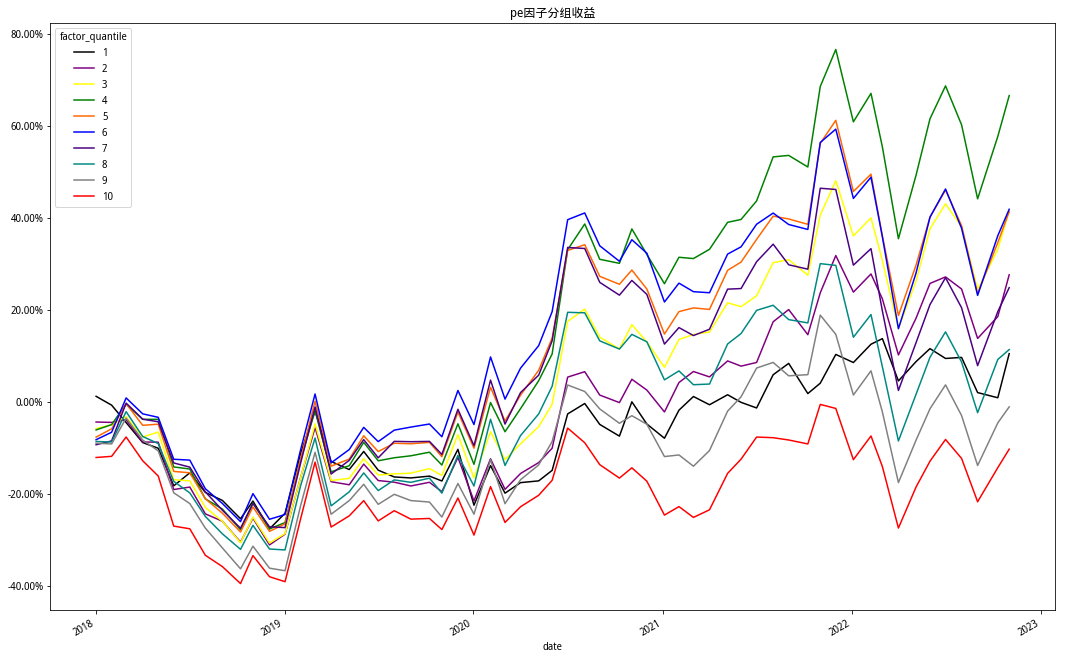

In [165]:
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('pe因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(valuation_ret).plot(ax=ax,color=color_map);
Strategy_performance(valuation_ret,'monthly').style.format('{:.2%}')

## 1.2 PB因子分层测试

In [12]:
# 获取PB 这里用的时间段与因子的一致
valuation_list = list(get_factor_pb_ratio(securities,periods))
valuation_df = pd.concat(valuation_list)
pivot_valuation = pd.pivot_table(valuation_df,
                         index='day',
                         columns='code',
                         values='pb_ratio')

In [92]:
#只取pb为正的
pivot_valuation = pivot_valuation[pivot_valuation > 0]
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)


Dropped 1.9% entries from factor data (1.9% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2,3,4,5,6,7,8,9,10
年化收益率,5.77%,8.42%,7.63%,5.95%,6.62%,6.26%,4.29%,0.63%,-0.43%,-2.14%
累计收益,31.79%,48.82%,43.57%,32.88%,37.04%,34.81%,22.94%,3.14%,-2.09%,-10.09%
波动率,22.79%,24.83%,25.32%,26.30%,26.44%,27.04%,26.94%,27.76%,27.89%,26.63%
夏普,35.69%,44.63%,41.42%,34.76%,37.17%,35.61%,28.69%,15.85%,12.05%,4.84%
最大回撤,-25.03%,-29.26%,-32.16%,-31.83%,-28.73%,-30.44%,-30.90%,-33.91%,-33.65%,-37.78%


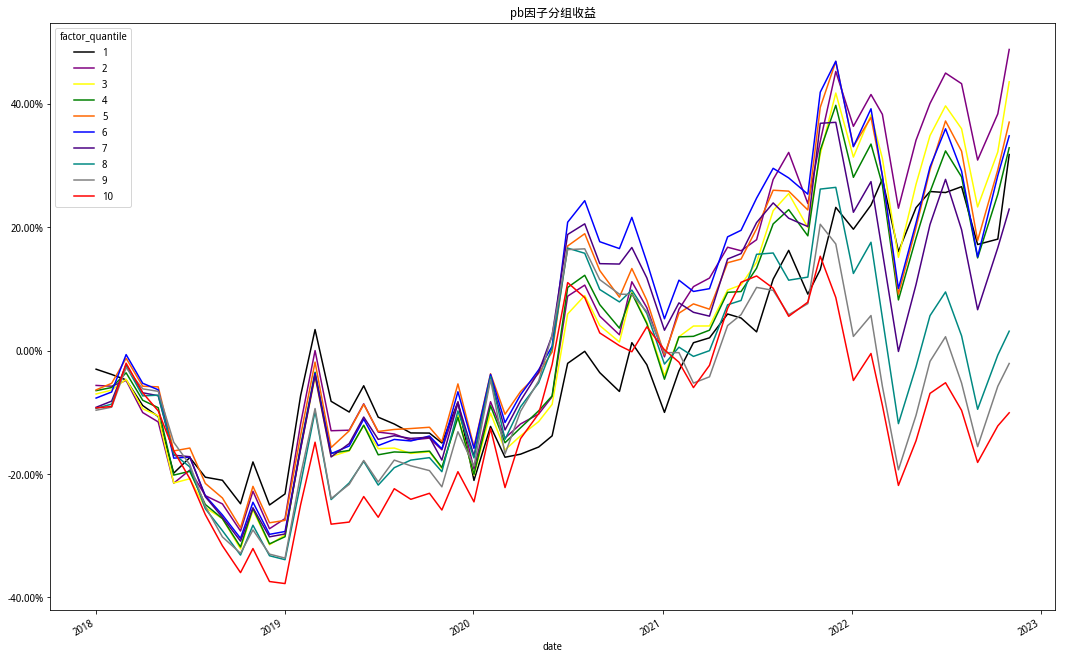

In [14]:
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('pb因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(valuation_ret).plot(ax=ax,color=color_map);
Strategy_performance(valuation_ret,'monthly').style.format('{:.2%}')

Dropped 1.9% entries from factor data (1.9% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2,3,4,5
年化收益率,7.15%,6.81%,6.46%,2.47%,-1.23%
累计收益,40.43%,38.23%,36.04%,12.74%,-5.91%
波动率,23.59%,25.75%,26.67%,27.27%,27.05%
夏普,40.73%,38.12%,36.47%,22.23%,8.59%
最大回撤,-27.06%,-32.00%,-29.58%,-32.04%,-35.72%


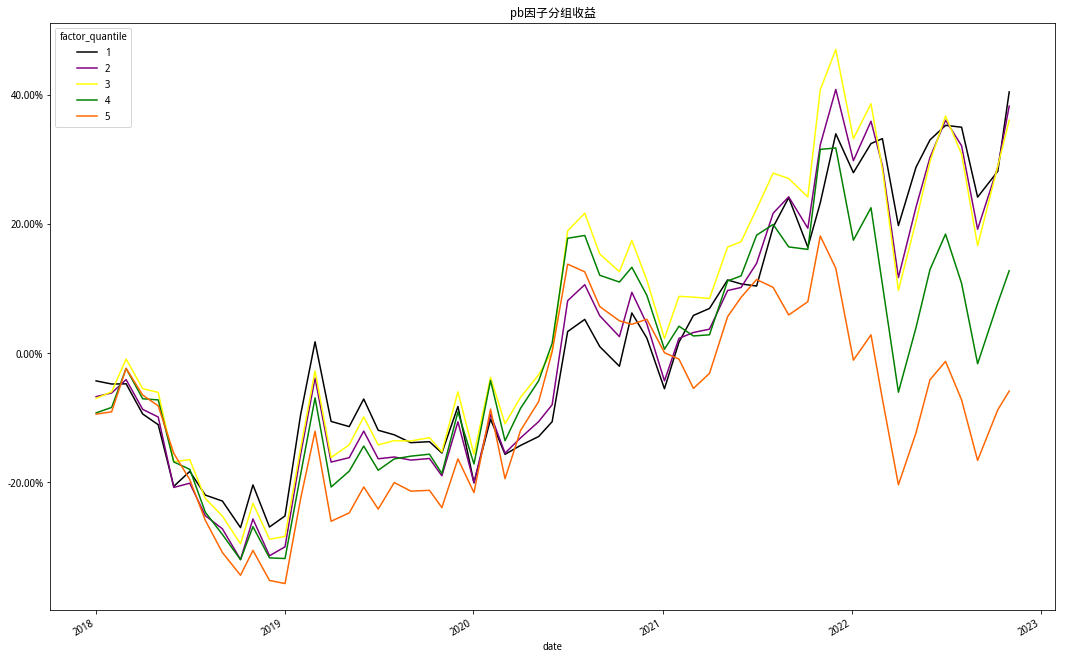

In [109]:
#5层分层
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 5,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('pb因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(valuation_ret).plot(ax=ax,color=color_map);
Strategy_performance(valuation_ret,'monthly').style.format('{:.2%}')

## 1.3 DP(股息率=最近一年分红/总市值)因子分层测试

In [172]:
# 获取dp 这里用的时间段与因子的一致
valuation_list = list(get_factor_dp(securities,periods,365))
valuation_df = pd.concat(valuation_list)
pivot_valuation = pd.pivot_table(valuation_df,
                         index='day',
                         columns='code',
                         values='dp')

In [173]:
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))

Dropped 2.0% entries from factor data (2.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2,3,4,5,6,7,8,9,10
年化收益率,-1.71%,1.81%,2.92%,2.38%,3.08%,7.08%,5.99%,7.54%,7.74%,7.81%
累计收益,-8.11%,9.23%,15.22%,12.27%,16.10%,39.95%,33.09%,42.95%,44.27%,44.73%
波动率,29.04%,27.47%,27.47%,26.11%,25.76%,25.07%,24.47%,23.66%,22.80%,20.70%
夏普,8.16%,19.92%,23.82%,21.69%,24.31%,39.50%,35.63%,42.26%,43.82%,46.46%
最大回撤,-40.33%,-34.96%,-34.00%,-33.46%,-33.84%,-28.91%,-30.02%,-28.68%,-26.71%,-21.93%


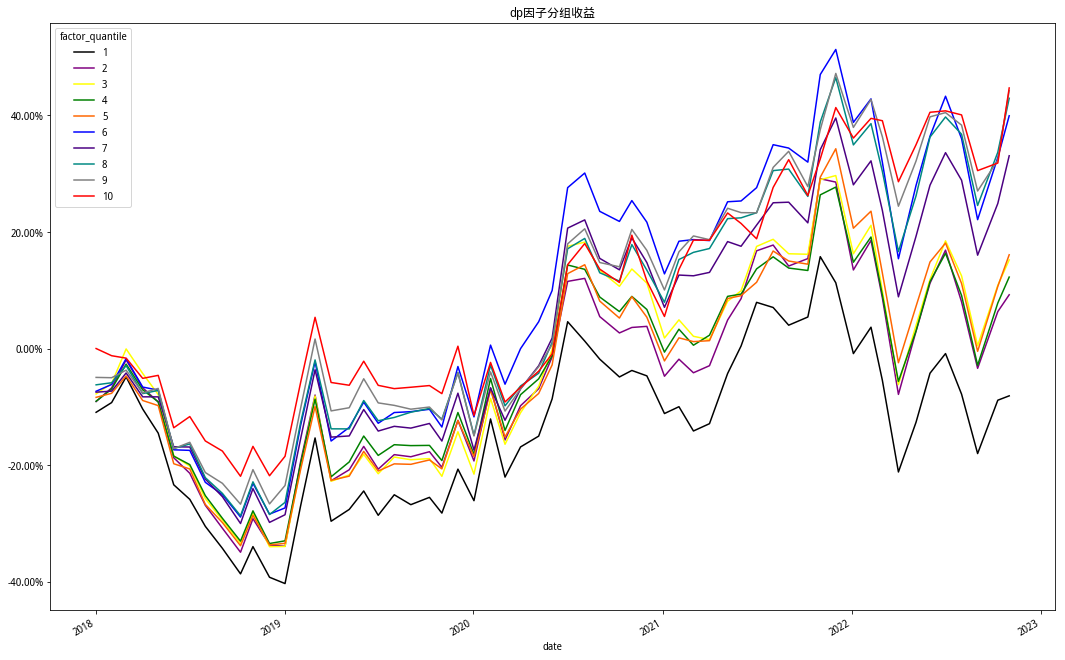

In [174]:
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('dp因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(valuation_ret).plot(ax=ax,color=color_map);
Strategy_performance(valuation_ret,'monthly').style.format('{:.2%}')

## 1.4 PS因子分层回测

In [180]:
# 获取PS 这里用的时间段与因子的一致
valuation_list = list(get_factor_ps_ratio(securities,periods))
valuation_df = pd.concat(valuation_list)
pivot_valuation = pd.pivot_table(valuation_df,
                         index='day',
                         columns='code',
                         values='ps_ratio')

In [181]:
#只取ps为正的
pivot_valuation = pivot_valuation[pivot_valuation > 0]
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))

Dropped 2.0% entries from factor data (2.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2,3,4,5,6,7,8,9,10
年化收益率,7.81%,7.14%,6.49%,8.10%,5.85%,6.57%,2.30%,1.89%,0.79%,-3.45%
累计收益,44.72%,40.35%,36.22%,46.69%,32.25%,36.76%,11.81%,9.66%,3.95%,-15.84%
波动率,23.09%,24.57%,24.79%,25.15%,26.04%,25.36%,26.34%,27.24%,27.80%,27.69%
夏普,43.80%,40.01%,37.45%,43.22%,34.51%,37.49%,21.46%,20.16%,16.40%,0.78%
最大回撤,-28.44%,-29.69%,-31.23%,-30.71%,-32.60%,-28.71%,-30.49%,-32.31%,-32.59%,-37.47%


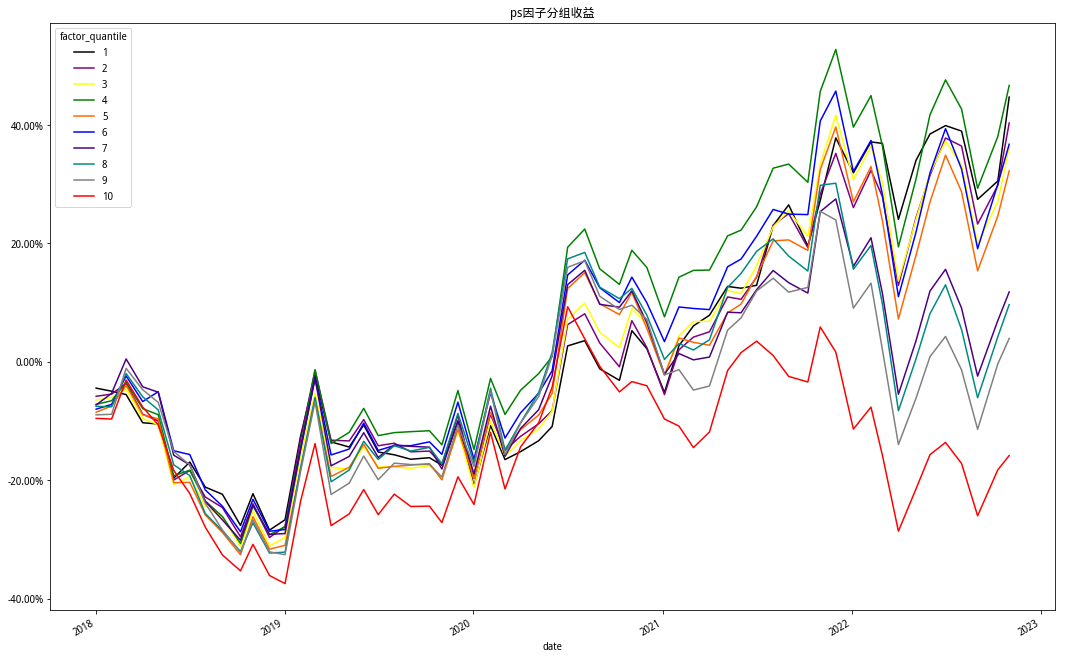

In [182]:
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('ps因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(valuation_ret).plot(ax=ax,color=color_map);
Strategy_performance(valuation_ret,'monthly').style.format('{:.2%}')

## 1.5 PCF因子分层回测

In [186]:
# 获取PCF 这里用的时间段与因子的一致
valuation_list = list(get_factor_pcf_ratio(securities,periods))
valuation_df = pd.concat(valuation_list)
pivot_valuation = pd.pivot_table(valuation_df,
                         index='day',
                         columns='code',
                         values='pcf_ratio')

In [187]:
#只取pcf为正的
pivot_valuation = pivot_valuation[pivot_valuation > 0]
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))

Dropped 2.0% entries from factor data (2.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2,3,4,5,6,7,8,9,10
年化收益率,4.94%,3.93%,5.87%,5.40%,3.70%,6.48%,4.33%,5.25%,5.30%,0.88%
累计收益,26.77%,20.85%,32.36%,29.48%,19.54%,36.19%,23.18%,28.59%,28.92%,4.41%
波动率,23.37%,25.16%,24.99%,24.64%,25.79%,25.19%,25.65%,26.76%,26.17%,25.25%
夏普,32.06%,27.55%,34.96%,33.32%,26.63%,37.22%,29.05%,32.15%,32.51%,15.79%
最大回撤,-27.26%,-27.94%,-29.91%,-28.86%,-31.92%,-31.44%,-31.21%,-31.42%,-31.87%,-31.87%


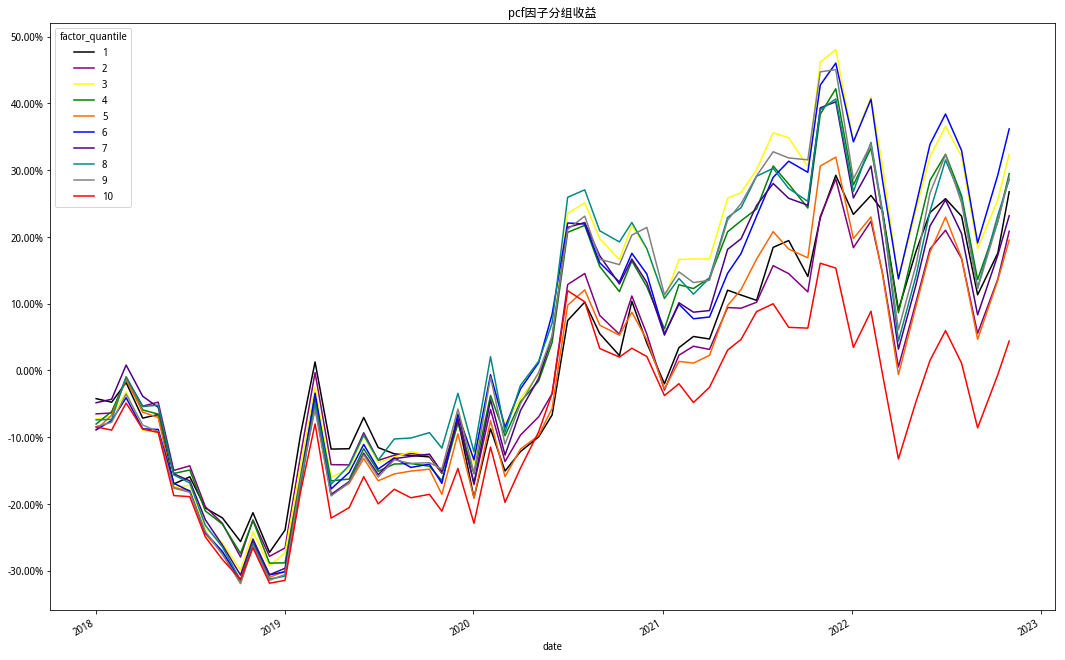

In [188]:
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('pcf因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(valuation_ret).plot(ax=ax,color=color_map);
Strategy_performance(valuation_ret,'monthly').style.format('{:.2%}')

In [208]:
dp_list = list(get_factor_dp(securities,price_periods,1825))

dp_df = pd.concat(dp_list)

pivot_dp = pd.pivot_table(dp_df,
                         index='day',
                         columns='code',
                         values='dp')

In [216]:
pe_list = list(get_factor_pe_ratio(securities,price_periods))

pe_df = pd.concat(pe_list)

pivot_pe = pd.pivot_table(pe_df,
                         index='day',
                         columns='code',
                         values='pe_ratio')

In [240]:
pivot_pe = pd.pivot_table(pe_df,
                         index='day',
                         columns='code',
                         values='pe_ratio')

In [237]:
#pivot_pe = pivot_pe.apply(lambda x: -1 * (x - x.quantile(0.5))**2, axis=1)

In [241]:
pivot_pe.index = pd.to_datetime(pivot_pe.index)
pe_ser = pivot_pe.stack()
pe_ser.index.names = ['date','asset']
pe_factor = al.utils.get_clean_factor_and_forward_returns(pe_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))


Dropped 1.9% entries from factor data (1.9% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


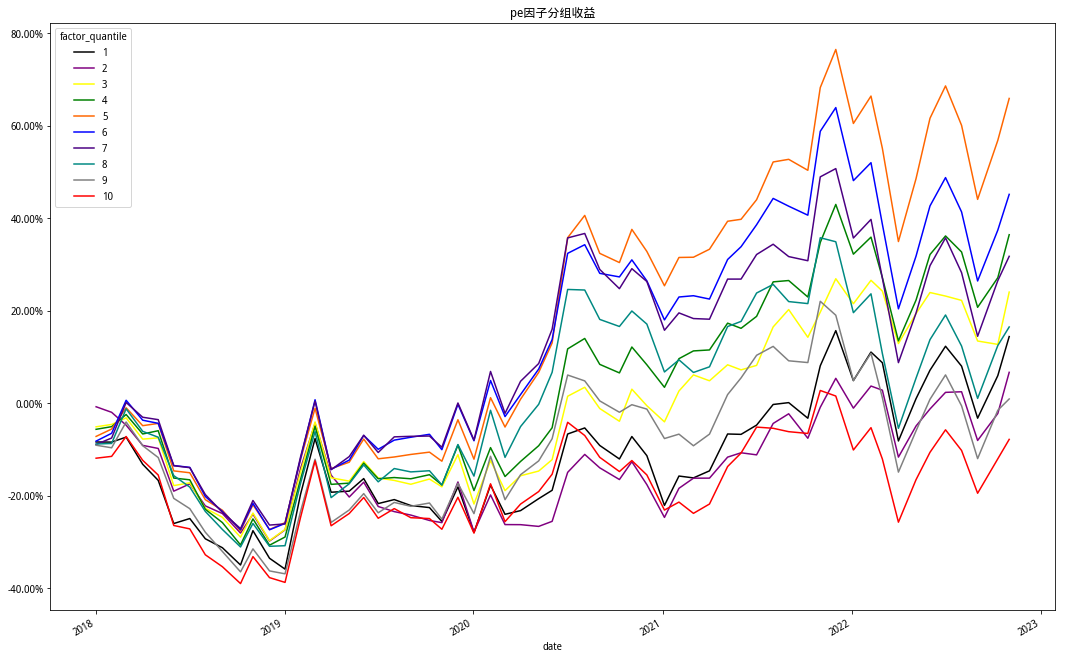

In [242]:
pe_ret = pd.pivot_table(pe_factor.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('pe因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))

color_map =['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(pe_ret).plot(ax=ax,color=color_map);

In [243]:
#pivot_dp = pivot_dp.apply(lambda x: -1 * (x - x.quantile(0.8))**2, axis=1)

# 2 调整FScore构造

## 2.1盈利水平

### 2.1.1 roa，delta_roa正负分层良好，保留

Dropped 2.2% entries from factor data (2.2% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


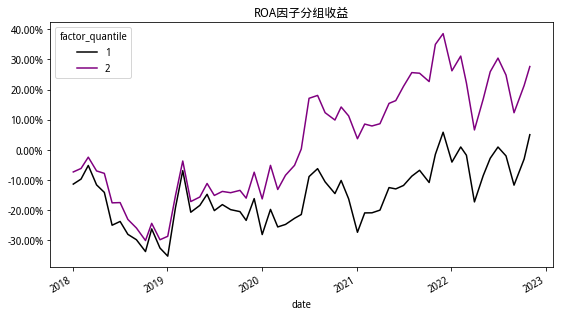

In [37]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['ROA'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('ROA因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
# Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 8.0% entries from factor data (8.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


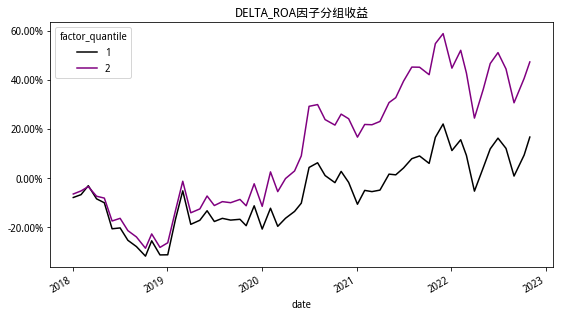

In [38]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['DELTA_ROA'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('DELTA_ROA因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
# Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

### 2.1.2 CFO与ACCRUAL正负分层不明显，删除

Dropped 2.4% entries from factor data (2.4% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,3.04%,5.53%
累计收益,15.84%,30.32%
波动率,27.26%,24.31%
夏普,24.20%,34.03%
最大回撤,-31.65%,-29.03%


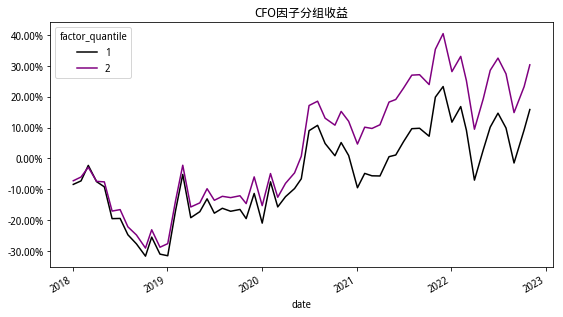

In [40]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['CFO'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('CFO因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 2.5% entries from factor data (2.5% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,4.16%,5.06%
累计收益,22.16%,27.49%
波动率,26.04%,24.42%
夏普,28.28%,32.17%
最大回撤,-30.28%,-30.17%


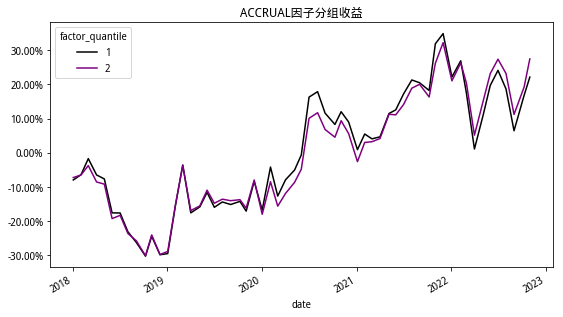

In [41]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['ACCRUAL'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('ACCRUAL因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

### 2.1.3 CFO与ACCRUAL构造修改

net_operate_cash_flow 	经营活动产生的现金流量净额(元) 	公式: 经营活动产生的现金流量净额, 是指某一季度，故将四个季度相加

total_assets 	资产总计(元) 这里取ttm

`cfo_sum: pd.DataFrame = (data['net_operate_cash_flow']+data['net_operate_cash_flow_1']+data['net_operate_cash_flow_2']+data['net_operate_cash_flow_3'])`

`fcfo: pd.DataFrame = data['net_operate_cash_flow'] / \
            data['total_assets']`

> 以下针对CFO和ACCRUAL单因子测试

In [71]:
#单因子测试
class CFOA(Factor):
    '''
    FScore原始模型
    '''
    name = 'CFOA'
    max_window = 1

    watch_date = None
    # paidin_capital 实收资本 股本变化会反应在该科目中
    dependencies = ['roa','net_operate_cash_flow','net_operate_cash_flow_1','net_operate_cash_flow_2'
                    ,'net_operate_cash_flow_3','net_operate_cash_flow_4','total_assets','total_assets_1'
                    ,'total_assets_2','total_assets_3','total_assets_4',
    
    ]

    def calc(self, data: Dict) -> None:
        roa: pd.DataFrame = data['roa']
            
        
        cfo_sum: pd.DataFrame = (data['net_operate_cash_flow']+data['net_operate_cash_flow_1']+data['net_operate_cash_flow_2']+\
            data['net_operate_cash_flow_3'])
            
        tt_ttm: pd.DataFrame = (data['total_assets']+data['total_assets_1']+data['total_assets_2']+\
            data['total_assets_3'])/4
        
        fcfo: pd.DataFrame = data['net_operate_cash_flow'] / \
            data['total_assets']
        
        fcfoa: pd.DataFrame = cfo_sum/tt_ttm
            
        fcfoa1: pd.DataFrame = cfo_sum/data['total_assets']

        accrual: pd.DataFrame = fcfoa - roa * 0.01
            
        accrual1: pd.DataFrame = fcfoa1 - roa * 0.01

        indicator_tuple: Tuple = (roa,cfo_sum,tt_ttm,fcfo,fcfoa,fcfoa1,accrual,accrual1)

        # 储存计算FFscore所需原始数据
        self.basic: pd.DataFrame = pd.concat(indicator_tuple).T.replace([-np.inf,np.inf],np.nan)
        self.basic.columns = [
            'roa','cfo_sum','tt_ttm','fcfo','fcfoa','fcfoa1','accrual','accrual1'
        ]


In [55]:
data_list = list(get_FFScore('A', CFOA, periods))

In [61]:
# basic_df1 = pd.read_csv('basic1.csv',
#                        index_col=[0,1], 
#                        parse_dates=[0])


> 测试结束，输出basic_df1，具体列名详见函数

Dropped 5.8% entries from factor data (5.8% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,2.26%,5.97%
累计收益,11.62%,32.97%
波动率,26.85%,24.50%
夏普,21.40%,35.62%
最大回撤,-32.24%,-28.79%


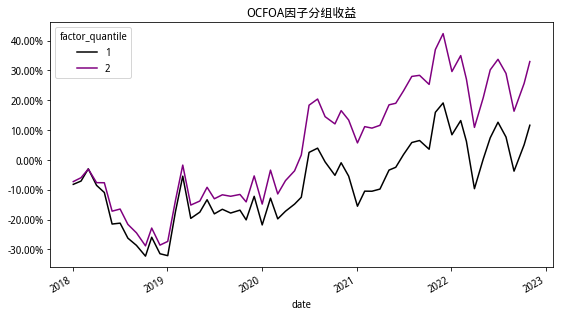

In [72]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df1['fcfoa'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('OCFOA因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 5.8% entries from factor data (5.8% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,3.00%,5.75%
累计收益,15.64%,31.65%
波动率,26.65%,24.44%
夏普,24.05%,34.81%
最大回撤,-32.08%,-28.78%


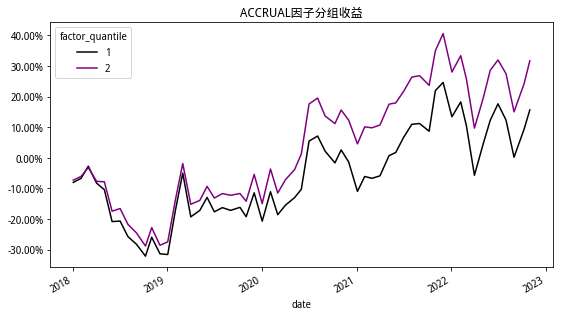

In [74]:
#可选择删除
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df1['accrual'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('ACCRUAL因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

## 2.2 财务杠杆和流动性

### 2.2.1 DELTA_LEVELER，DLTA_LIQUID，EQ_OFFSER正负分层均表现不好，删除

Dropped 12.5% entries from factor data (12.5% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,5.13%,6.09%
累计收益,27.90%,33.74%
波动率,25.37%,25.23%
夏普,32.09%,35.75%
最大回撤,-32.25%,-29.59%


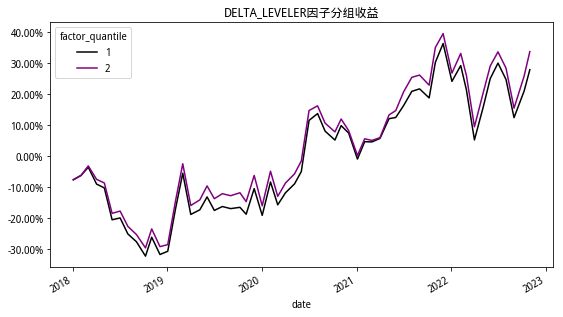

In [80]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['DELTA_LEVELER'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('DELTA_LEVELER因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 10.0% entries from factor data (10.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,6.63%,4.33%
累计收益,37.11%,23.18%
波动率,25.55%,25.10%
夏普,37.59%,29.14%
最大回撤,-30.30%,-31.42%


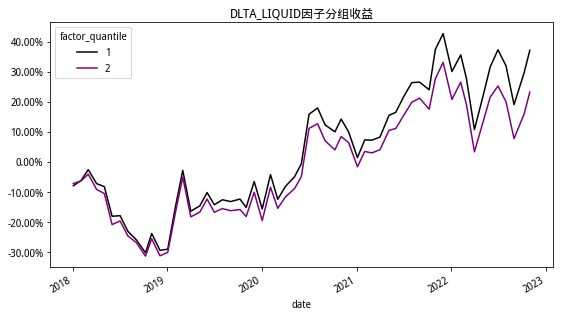

In [81]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['DLTA_LIQUID'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('DLTA_LIQUID因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 8.0% entries from factor data (8.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,6.16%,4.86%
累计收益,34.19%,26.30%
波动率,25.19%,25.16%
夏普,36.05%,31.12%
最大回撤,-30.80%,-30.26%


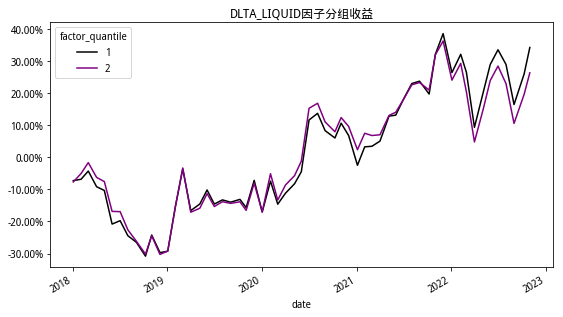

In [82]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['EQ_OFFSER'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('EQ_OFFSER因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

>以下针对财务杠杆和流动性测试

In [85]:
class LEVELER(Factor):

    name = 'LEVELER'
    max_window = 1

    watch_date = None
    # paidin_capital 实收资本 股本变化会反应在该科目中
    dependencies = ['total_non_current_liability','total_non_current_liability_1','total_non_current_liability_4',
                    'total_assets','total_assets_1','total_assets_4','total_current_assets','total_current_assets_1',
                    'total_current_assets_4','total_current_liability','total_current_liability_1','total_current_liability_4']

    def calc(self, data: Dict) -> None:
        leveler: pd.DataFrame = data['total_non_current_liability'] / data['total_assets']
        leveler1: pd.DataFrame = data['total_non_current_liability_1'] / data['total_assets_1']
        leveler4: pd.DataFrame = data['total_non_current_liability_4'] / data['total_assets_4']
            
        delta_leveler1: pd.DataFrame = -(leveler / leveler1 - 1)
        delta_leveler4: pd.DataFrame = -(leveler / leveler4 - 1)

        liquid: pd.DataFrame = data['total_current_assets'] / data['total_current_liability']
        liquid_1: pd.DataFrame = data['total_current_assets_1'] / data['total_current_liability_1']
        liquid_4: pd.DataFrame = data['total_current_assets_4'] / data['total_current_liability_4']

        delta_liquid1: pd.DataFrame = liquid / liquid_1 - 1
        delta_liquid4: pd.DataFrame = liquid / liquid_4 - 1
            
        #股本增发暂时不处理
        indicator_tuple: Tuple = (delta_leveler1,delta_leveler4,delta_liquid1,delta_liquid4)

        # 储存计算FFscore所需原始数据
        self.basic: pd.DataFrame = pd.concat(indicator_tuple).T.replace([-np.inf,np.inf],np.nan)
        self.basic.columns = [
            'delta_leveler1','delta_leveler4','delta_liquid1','delta_liquid4'
        ]


In [86]:
data_list = list(get_FFScore('A', LEVELER, periods))

In [88]:
# # 基础数据
# basic_df1: pd.DataFrame = pd.concat({f.watch_date: f.basic
#                                     for f in data_list},
#                                    names=['date', 'asset'])
# # 储存数据
# basic_df1.to_csv('basic1.csv')

basic_df1 = pd.read_csv('basic1.csv',
                       index_col=[0,1], 
                       parse_dates=[0])


> 测试结束

### 2.2.2 只保留修改后的delta_leveler

Dropped 6.4% entries from factor data (6.4% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,3.76%,6.28%
累计收益,19.89%,34.89%
波动率,25.02%,25.70%
夏普,26.95%,36.21%
最大回撤,-32.32%,-29.59%


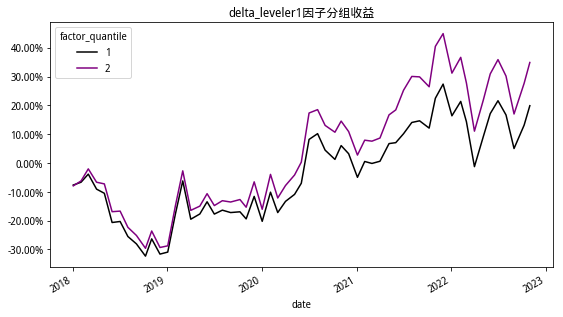

In [92]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df1['delta_leveler1'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('delta_leveler1因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 4.5% entries from factor data (4.5% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,5.80%,4.17%
累计收益,31.94%,22.24%
波动率,25.94%,24.86%
夏普,34.37%,28.56%
最大回撤,-29.80%,-31.44%


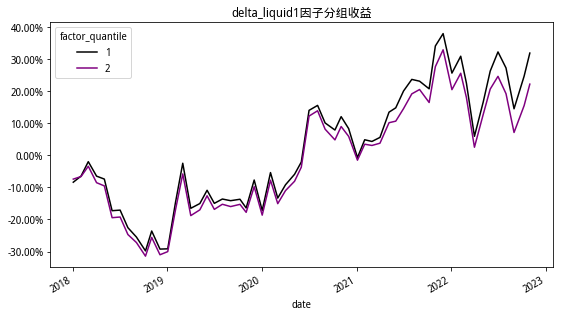

In [95]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df1['delta_liquid1'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('delta_liquid1因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

## 2.3 运营效率：分离均不错，保留
代表了运营效率的指标为毛利润率变化( ΔMARGIN )与资产周转率变化( ΔTURN )。毛利润的增加意味着公司的成本降低或者产品售价提高。资产周转率增加则反映了公司运营周转效率的提升。因此，这两个指标有效的表示了企业在运营方面的能力提高，从而为其未来生存竞争力与公司的成长提供有力的支持。

Dropped 9.4% entries from factor data (9.4% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,3.74%,7.42%
累计收益,19.76%,42.18%
波动率,25.65%,25.00%
夏普,26.78%,40.85%
最大回撤,-31.71%,-29.72%


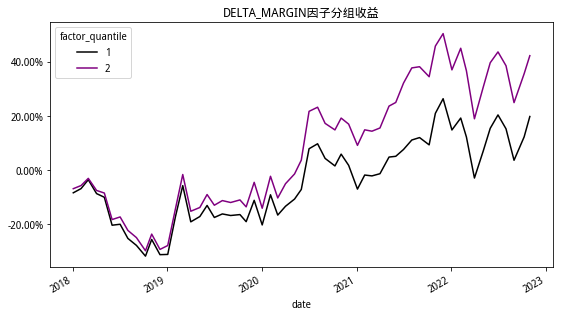

In [96]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['DELTA_MARGIN'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('DELTA_MARGIN因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 9.7% entries from factor data (9.7% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1,2
年化收益率,2.70%,7.87%
累计收益,14.01%,45.13%
波动率,25.43%,25.06%
夏普,22.87%,42.44%
最大回撤,-31.88%,-29.72%


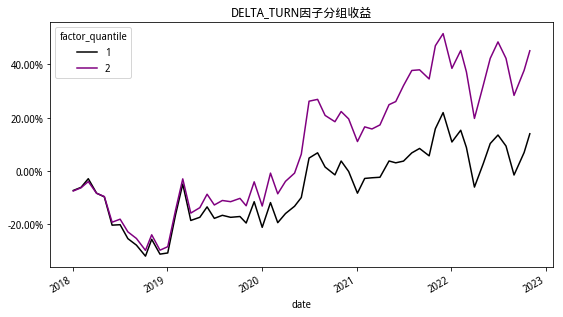

In [97]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(basic_df['DELTA_TURN'],
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[-inf,0,inf],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reset_index(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('DELTA_TURN因子分组收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
color_map = ['#000000', '#800080',  '#FFFF00', '#008000', '#FF6600','#0000FF', '#4B0082', '#008982', '#808080', '#FF0000']
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=color_map);
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

## 2.4 重构后的FScore模型——RFScore(7分制)

In [98]:


class RFScore(Factor):
    '''
    RFScore原始模型
    '''
    name = 'RFScore'
    max_window = 1

    watch_date = None
    # paidin_capital 实收资本 股本变化会反应在该科目中
    dependencies = [
        'roa', 'roa_4','net_operate_cash_flow','net_operate_cash_flow_1','net_operate_cash_flow_2',
        'net_operate_cash_flow_3','total_assets','total_assets_1','total_assets_2','total_assets_3',
        'total_assets_4','total_assets_5',
        'total_non_current_liability','total_non_current_liability_1','gross_profit_margin',
        'gross_profit_margin_4','operating_revenue','operating_revenue_4'
    ]

    def calc(self, data: Dict) -> None:

        roa: pd.DataFrame = data['roa'] # 单位为百分号

        delta_roa: pd.DataFrame = roa / data['roa_4'] - 1

        cfo_sum: pd.DataFrame = (data['net_operate_cash_flow']+data['net_operate_cash_flow_1']+data['net_operate_cash_flow_2']+\
            data['net_operate_cash_flow_3'])
        
        ta_ttm: pd.DataFrame = (data['total_assets']+data['total_assets_1']+data['total_assets_2']+\
            data['total_assets_3'])/4
            
        ocfoa: pd.DataFrame = cfo_sum/ta_ttm
            
        accrual: pd.DataFrame = ocfoa - roa * 0.01
            
        #杠杆变化    
        leveler: pd.DataFrame = data['total_non_current_liability'] / data['total_assets']
        leveler1: pd.DataFrame = data['total_non_current_liability_1'] / data['total_assets_1']    

            
        delta_leveler: pd.DataFrame = -(leveler / leveler1 - 1)
            
        # 毛利率变化
        delta_margin: pd.DataFrame = data['gross_profit_margin'] / \
            data['gross_profit_margin_4'] - 1
            
        # 总资产周转率
        total_asset_turnover_rate: pd.DataFrame = data[
            'operating_revenue'] / (data['total_assets'] +
                                          data['total_assets_1']).mean()

        total_asset_turnover_rate_1: pd.DataFrame = data[
            'operating_revenue_4'] / (data['total_assets_4'] +
                                            data['total_assets_5']).mean()

        # 总资产周转率同比
        delta_turn: pd.DataFrame = total_asset_turnover_rate / \
            total_asset_turnover_rate_1 - 1
        
        
        indicator_tuple: Tuple = (roa, delta_roa, ocfoa, accrual, delta_leveler,
                                   delta_margin, delta_turn)
        # 储存计算RFscore所需原始数据
        self.basic: pd.DataFrame = pd.concat(indicator_tuple).T.replace([-np.inf,np.inf],np.nan)
        
        
        self.basic.columns = [
            'ROA', 'DELTA_ROA', 'OCFOA','ACCRUAL', 'DELTA_LEVELER',
             'DELTA_MARGIN', 'DELTA_TURN',]
        
        self.fscore: pd.Series = self.basic.apply(sign).sum(axis=1)

In [99]:
data_list = list(get_FFScore('A', RFScore, periods))

In [100]:
# 因子值
RFScore_factor: pd.Series = pd.concat(
    {pd.to_datetime(f.watch_date): f.fscore
     for f in data_list},
    names=['date', 'asset'])

# 基础数据
Rbasic_df: pd.DataFrame = pd.concat({f.watch_date: f.basic
                                    for f in data_list},
                                   names=['date', 'asset'])

In [101]:
# 储存数据
# RFScore_factor.to_frame('RFScore').to_csv('RFScore.csv')
# Rbasic_df.to_csv('Rbasic.csv')

In [62]:
RFScore_factor = pd.read_csv('RFScore.csv', 
                             index_col=[0,1], 
                             parse_dates=[0])
Rbasic_df = pd.read_csv('Rbasic.csv',
                       index_col=[0,1], 
                       parse_dates=[0])

# 3 修改后的FScore模型与原模型比较：以PB为例

## 3.1 原模型

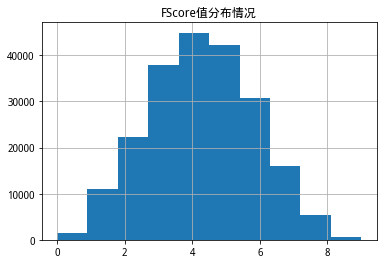

In [15]:
plt.title('FScore值分布情况')
FScore_factor['FScore'].hist();

Dropped 2.8% entries from factor data (2.1% after in forward returns computation and 0.7% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
年化收益率,-0.26%,-0.75%,1.51%,3.82%,5.20%,8.99%,10.95%,10.69%,14.78%
累计收益,-1.28%,-3.62%,7.65%,20.24%,28.33%,52.69%,66.69%,64.73%,96.93%
波动率,27.64%,27.29%,26.01%,25.69%,24.97%,24.39%,24.05%,22.36%,30.58%
夏普,12.47%,10.49%,18.41%,27.10%,32.53%,47.19%,55.01%,56.49%,60.28%
最大回撤,-32.73%,-31.42%,-31.95%,-31.68%,-28.87%,-28.88%,-25.10%,-26.01%,-52.40%


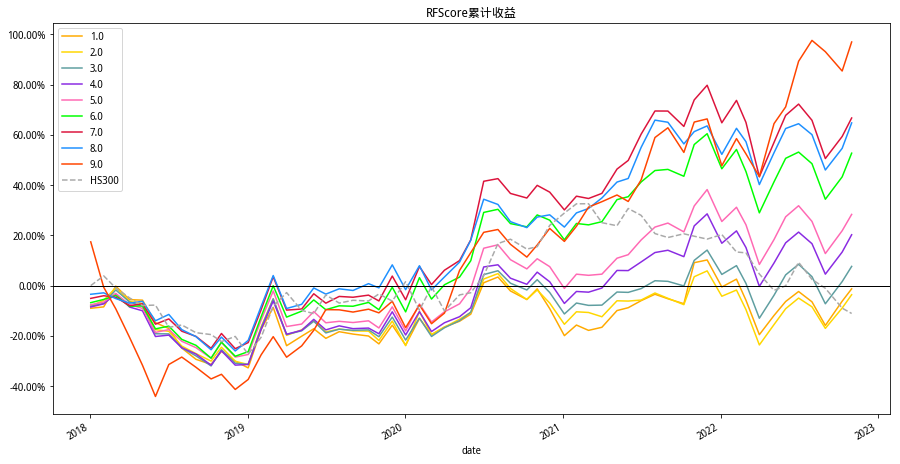

In [20]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(FScore_factor,
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[0,1,2,3,4,5,6,7,8,9],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reindex(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_title('RFScore累计收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=['#FFAA00', '#FFD700', '#5F9EA0', '#8A2BE2', '#FF69B4', '#00FF00', '#DC143C', '#1E90FF', '#FF4500'])
ep.cum_returns(benchmark_ret.reindex(fscore_factor_ret.index)).plot(ax=ax,
                                   label='HS300',
                                   color='darkgray',
                                   ls='--')
ax.axhline(0, color='black', lw=1)
plt.legend();
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

In [21]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        5.0
           000004.XSHE -0.110076        ...                       10.0
           000005.XSHE -0.104167        ...                        6.0
           000008.XSHE -0.067282        ...                        7.0

[5 rows x 4 columns]

### 3.1.1 FScore9分与PB10%，数量太少，无法形成比较

,比乔斯基9指标模型策略,FScore9分组,PB因子(10%),benchmark
年化收益率,1.15%,14.78%,5.77%,0.18%
累计收益,5.78%,96.93%,31.79%,0.86%
波动率,41.95%,30.58%,22.79%,20.86%
夏普,23.45%,60.28%,35.69%,11.36%
最大回撤,-47.98%,-52.40%,-25.03%,-28.49%
IR,4.27%,14.20%,7.83%,nan%
Alpha,10.82%,18.76%,11.27%,nan%
超额收益,0.97%,14.60%,5.60%,0.00%


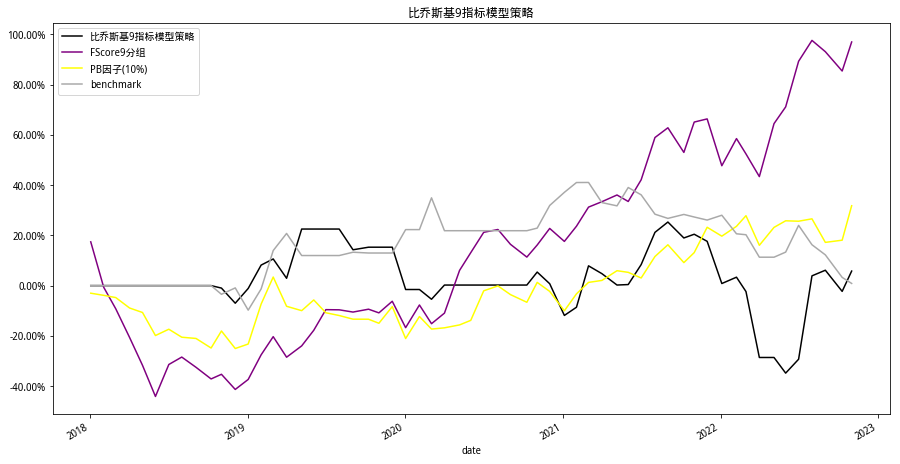

In [24]:
cross_df = df.query('Fundamental_group == 1 and factor_quantile == 9')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基9指标模型策略')

all_ret = pd.concat((cross_ret[9],fscore_factor_ret[9],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基9指标模型策略','FScore9分组','PB因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

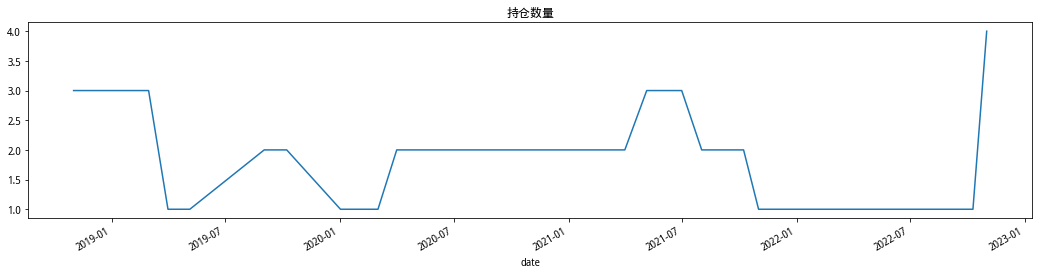

In [23]:
cross_df.groupby(level='date')['factor'].count().plot(title='持仓数量',figsize=(18,4));

### 3.1.2 FScore8-9分与PB10%

In [91]:
fscore_factor_data = al.utils.get_clean_factor_and_forward_returns(FScore_factor,
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[0,1,2,3,4,5,6,7,9],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reindex(),index='date',columns='factor_quantile',values=1)

Dropped 2.8% entries from factor data (2.1% after in forward returns computation and 0.7% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [93]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        5.0
           000004.XSHE -0.110076        ...                       10.0
           000005.XSHE -0.104167        ...                        6.0
           000008.XSHE -0.067282        ...                        7.0

[5 rows x 4 columns]

,比乔斯基9指标模型策略,FScore8-9分组,PB因子(10%),benchmark
年化收益率,13.03%,11.47%,5.77%,-2.36%
累计收益,82.59%,70.55%,31.79%,-11.09%
波动率,26.30%,22.07%,22.79%,20.37%
夏普,59.02%,60.17%,35.69%,-2.04%
最大回撤,-27.71%,-26.91%,-25.03%,-32.93%
IR,14.00%,13.45%,8.55%,nan%
Alpha,15.89%,14.12%,8.87%,nan%
超额收益,15.39%,13.83%,8.14%,0.00%


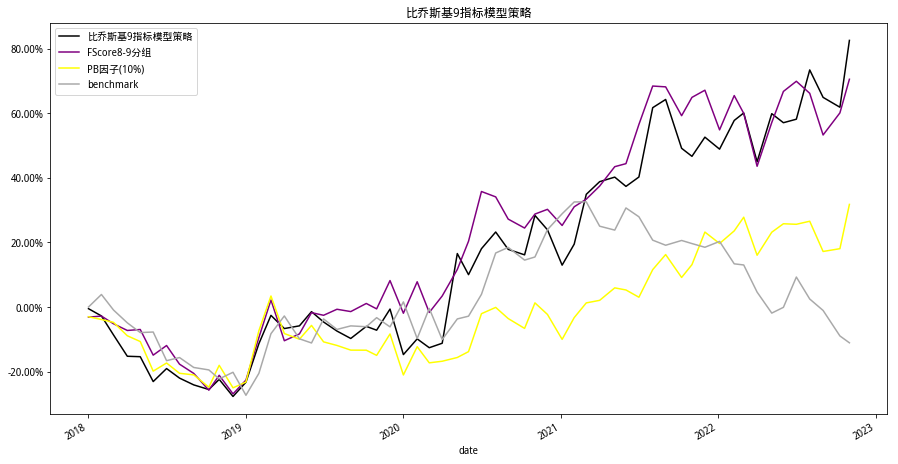

In [94]:
cross_df = df.query('Fundamental_group == 1 and factor_quantile == 8')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基9指标模型策略')

all_ret = pd.concat((cross_ret[8],fscore_factor_ret[8],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基9指标模型策略','FScore8-9分组','PB因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

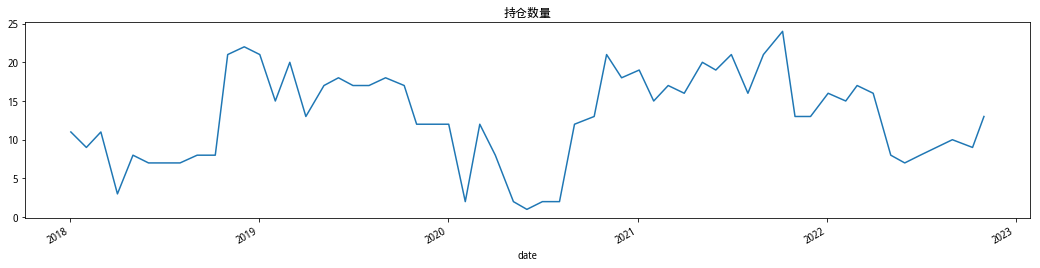

In [95]:
cross_df.groupby(level='date')['factor'].count().plot(title='持仓数量',figsize=(18,4));

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


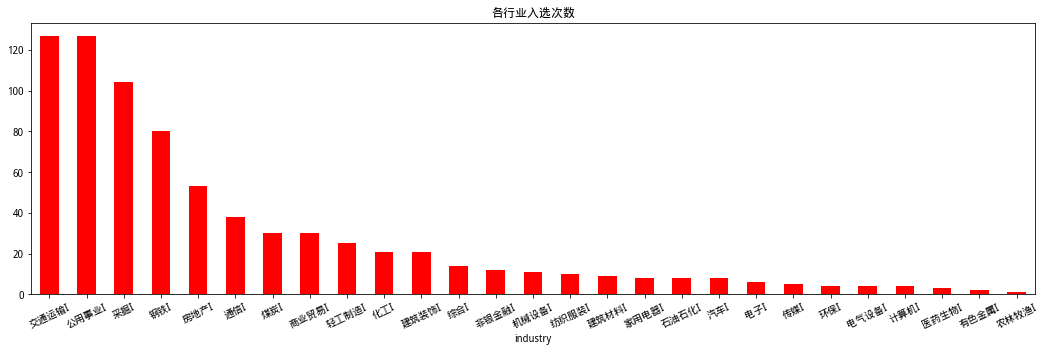

In [96]:
cross_df['industry'] = cross_df.groupby(
    level='date').apply(lambda x: get_stock_ind(
        x.index.get_level_values(1).values.tolist(), x.name, 'sw_l1',
        'industry_name'))
cross_df.groupby('industry')[1].count().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5), title='各行业入选次数',rot=25);

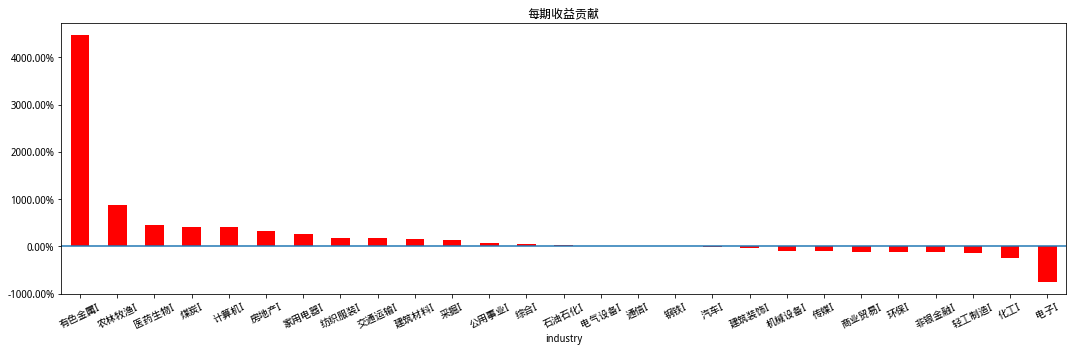

In [97]:
fig,ax = plt.subplots(figsize=(18,5))

ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'{:.2%}'.format(x * 100)))
cross_df.groupby('industry')[1].mean().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5),title='每期收益贡献',ax=ax,rot=25)
plt.axhline(0);

In [107]:
cross_df[cross_df['industry']=='有色金属I']

,,1,factor,factor_quantile,Fundamental_group,industry
date,asset,,,,,
2020-11-02,601600.XSHG,0.412162,8.0,8.0,1.0,有色金属I
2021-07-01,600219.XSHG,0.482827,8.0,8.0,1.0,有色金属I


In [108]:
cross_df[cross_df['industry']=='农林牧渔I']

,,1,factor,factor_quantile,Fundamental_group,industry
date,asset,,,,,
2019-03-01,002772.XSHE,0.087121,8.0,8.0,1.0,农林牧渔I


### 3.1.2 FScore8-9分与PB20%

In [47]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        3.0
           000004.XSHE -0.110076        ...                        5.0
           000005.XSHE -0.104167        ...                        3.0
           000008.XSHE -0.067282        ...                        4.0

[5 rows x 4 columns]

,比乔斯基9指标模型策略,FScore8-9分组,PB因子(20%),benchmark
年化收益率,14.70%,11.47%,7.15%,-2.36%
累计收益,96.30%,70.55%,40.43%,-11.09%
波动率,24.64%,22.07%,23.59%,20.37%
夏普,67.63%,60.17%,40.73%,-2.04%
最大回撤,-29.06%,-26.91%,-27.06%,-32.93%
IR,16.22%,13.45%,10.00%,nan%
Alpha,17.45%,14.12%,10.65%,nan%
超额收益,17.07%,13.83%,9.51%,0.00%


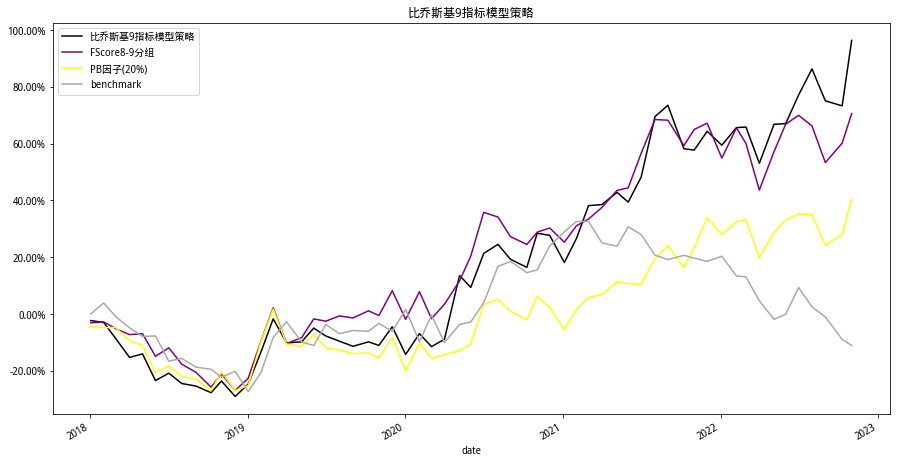

In [48]:
cross_df = df.query('Fundamental_group == 1 and factor_quantile == 8')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基9指标模型策略')

all_ret = pd.concat((cross_ret[8],fscore_factor_ret[8],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基9指标模型策略','FScore8-9分组','PB因子(20%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

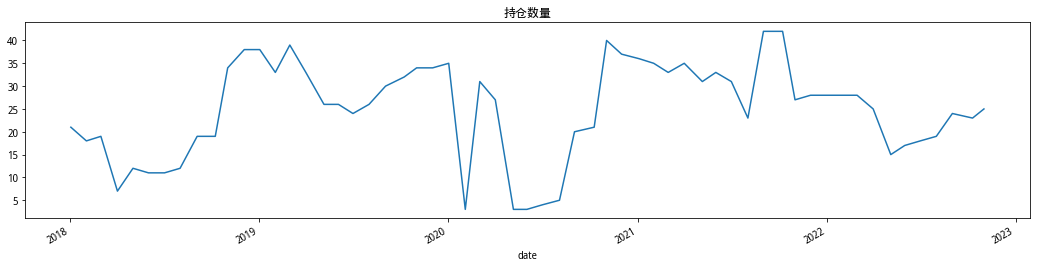

In [49]:
cross_df.groupby(level='date')['factor'].count().plot(title='持仓数量',figsize=(18,4));

In [50]:
cross_df['industry'] = cross_df.groupby(
    level='date').apply(lambda x: get_stock_ind(
        x.index.get_level_values(1).values.tolist(), x.name, 'sw_l1',
        'industry_name'))

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


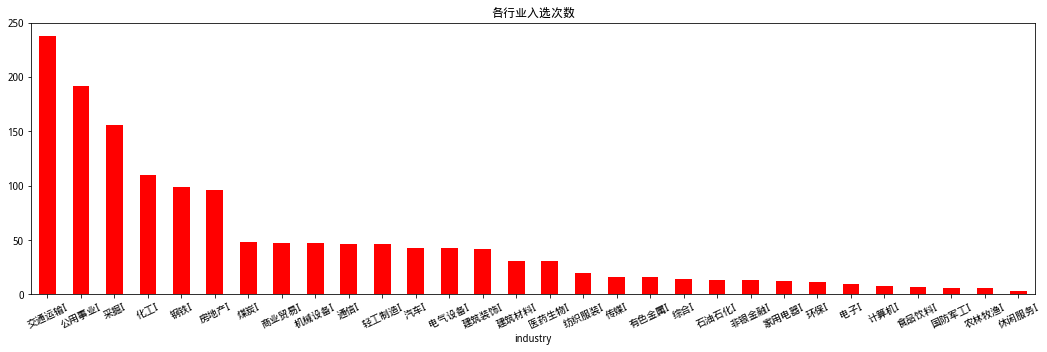

In [52]:
cross_df.groupby('industry')[1].count().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5), title='各行业入选次数',rot=25);

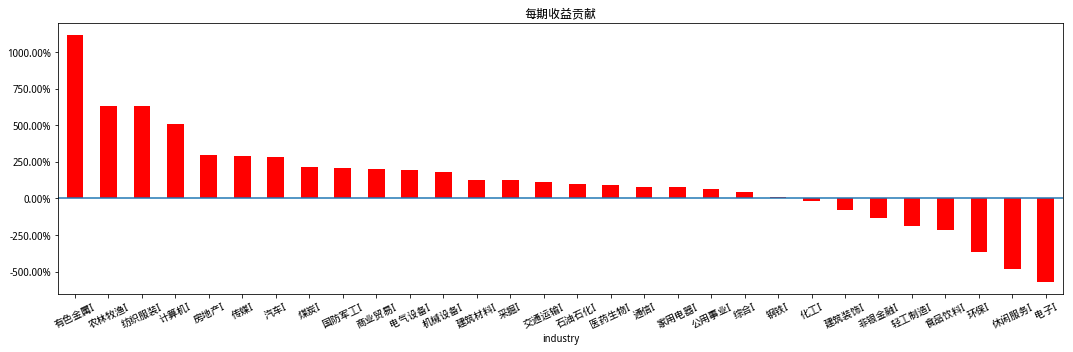

In [54]:
fig,ax = plt.subplots(figsize=(18,5))

ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'{:.2%}'.format(x * 100)))
cross_df.groupby('industry')[1].mean().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5),title='每期收益贡献',ax=ax,rot=25)
plt.axhline(0);

## 3.2 修改后的FScore模型

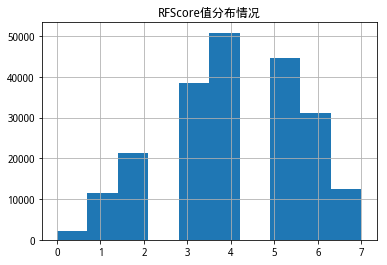

In [63]:
plt.title('RFScore值分布情况')
RFScore_factor['RFScore'].hist();

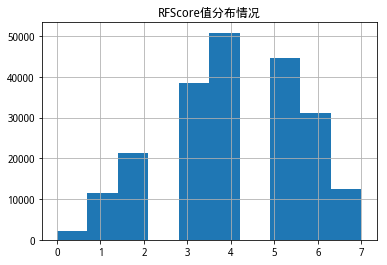

In [109]:
plt.title('RFScore值分布情况')
RFScore_factor['RFScore'].hist();

Dropped 3.1% entries from factor data (2.1% after in forward returns computation and 1.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1.0,2.0,3.0,4.0,5.0,6.0,7.0
年化收益率,-2.07%,-2.94%,2.03%,2.51%,7.20%,9.90%,14.53%
累计收益,-9.77%,-13.66%,10.36%,12.99%,40.74%,59.04%,94.83%
波动率,28.26%,26.86%,25.62%,25.45%,24.60%,24.54%,25.03%
夏普,6.35%,2.00%,20.33%,22.15%,40.25%,50.48%,66.35%
最大回撤,-34.79%,-33.08%,-32.55%,-30.94%,-29.55%,-28.41%,-23.70%


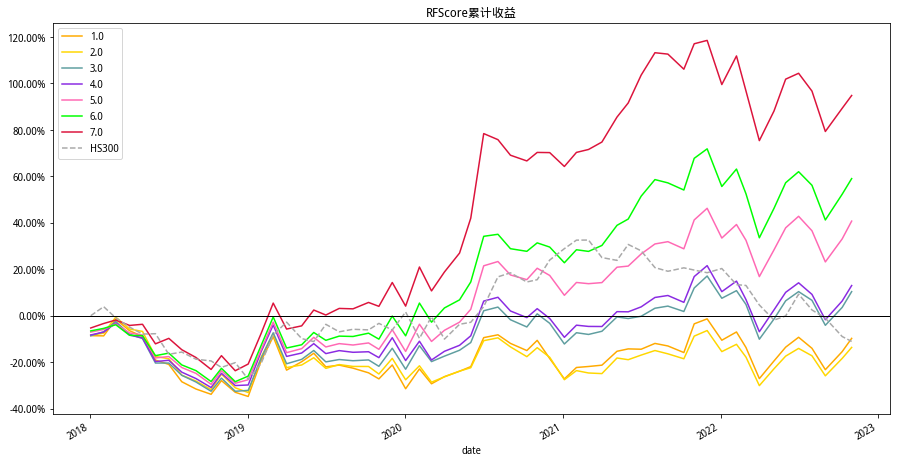

In [121]:
fscore_factor_data  = al.utils.get_clean_factor_and_forward_returns(RFScore_factor,
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[0,1,2,3,4,5,6,7],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reindex(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_title('RFScore累计收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=['#FFAA00', '#FFD700', '#5F9EA0', '#8A2BE2', '#FF69B4', '#00FF00', '#DC143C', '#1E90FF', '#FF4500'])
ep.cum_returns(benchmark_ret.reindex(fscore_factor_ret.index)).plot(ax=ax,
                                   label='HS300',
                                   color='darkgray',
                                   ls='--')
ax.axhline(0, color='black', lw=1)
plt.legend();
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

Dropped 3.1% entries from factor data (2.1% after in forward returns computation and 1.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


factor_quantile,1.0,2.0,3.0,4.0,5.0,6.0,7.0
年化收益率,-2.07%,-2.94%,2.03%,2.51%,7.20%,9.90%,14.53%
累计收益,-9.77%,-13.66%,10.36%,12.99%,40.74%,59.04%,94.83%
波动率,28.26%,26.86%,25.62%,25.45%,24.60%,24.54%,25.03%
夏普,6.35%,2.00%,20.33%,22.15%,40.25%,50.48%,66.35%
最大回撤,-34.79%,-33.08%,-32.55%,-30.94%,-29.55%,-28.41%,-23.70%


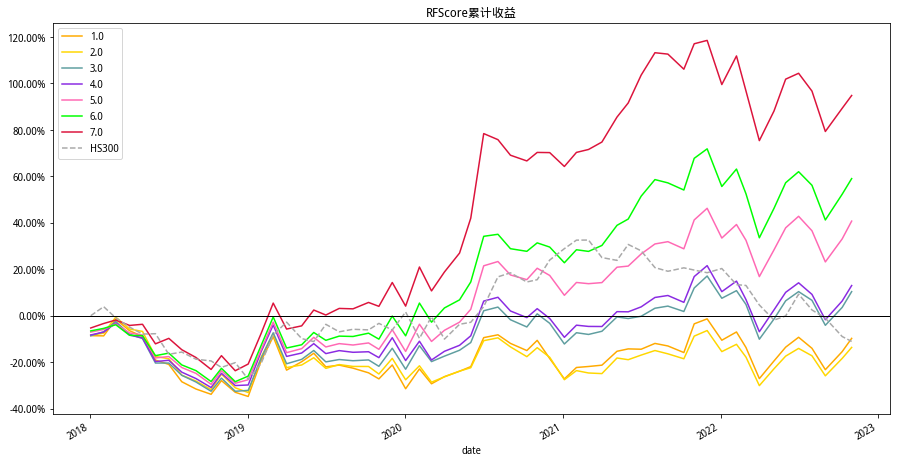

In [64]:
fscore_factor_data  = al.utils.get_clean_factor_and_forward_returns(RFScore_factor,
                                                           pivot_price,
                                                           quantiles = None,
                                                           bins=[0,1,2,3,4,5,6,7],
                                                           periods=(1,))
fscore_factor_ret = pd.pivot_table(fscore_factor_data.reindex(),index='date',columns='factor_quantile',values=1)
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_title('RFScore累计收益')
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, pos: '%.2f%%' % (x * 100)))
ep.cum_returns(fscore_factor_ret).plot(ax=ax,color=['#FFAA00', '#FFD700', '#5F9EA0', '#8A2BE2', '#FF69B4', '#00FF00', '#DC143C', '#1E90FF', '#FF4500'])
ep.cum_returns(benchmark_ret.reindex(fscore_factor_ret.index)).plot(ax=ax,
                                   label='HS300',
                                   color='darkgray',
                                   ls='--')
ax.axhline(0, color='black', lw=1)
plt.legend();
Strategy_performance(fscore_factor_ret,'monthly').style.format('{:.2%}')

### 3.2.1 RFScore7分与PB10%

In [78]:
#只取pb为正的

valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)

Dropped 1.9% entries from factor data (1.9% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [79]:
#给出对应RFScore与PB因子对应层数
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        5.0
           000004.XSHE -0.110076        ...                       10.0
           000005.XSHE -0.104167        ...                        6.0
           000008.XSHE -0.067282        ...                        7.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PB因子(10%),benchmark
年化收益率,17.94%,14.53%,5.77%,-2.36%
累计收益,125.03%,94.83%,31.79%,-11.09%
波动率,25.38%,25.03%,22.79%,20.37%
夏普,77.62%,66.35%,35.69%,-2.04%
最大回撤,-20.71%,-23.70%,-25.03%,-32.93%
IR,18.12%,16.19%,8.55%,nan%
Alpha,20.31%,17.97%,8.87%,nan%
超额收益,20.30%,16.89%,8.14%,0.00%


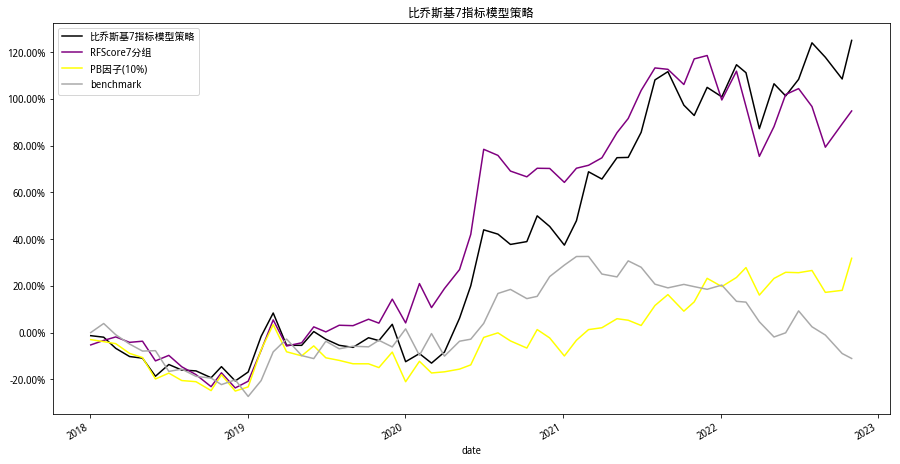

In [80]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

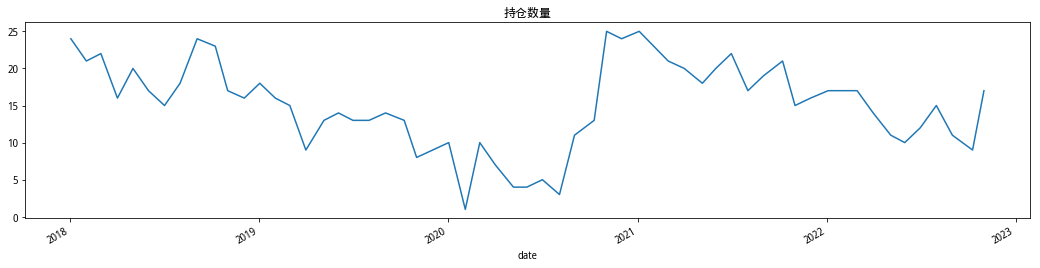

In [81]:
cross_df.groupby(level='date')['factor'].count().plot(title='持仓数量',figsize=(18,4));

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


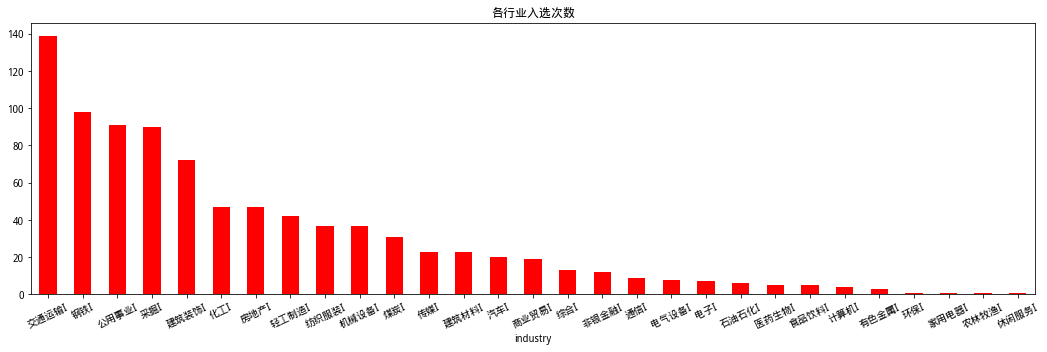

In [82]:
cross_df['industry'] = cross_df.groupby(
    level='date').apply(lambda x: get_stock_ind(
        x.index.get_level_values(1).values.tolist(), x.name, 'sw_l1',
        'industry_name'))
cross_df.groupby('industry')[1].count().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5), title='各行业入选次数',rot=25);

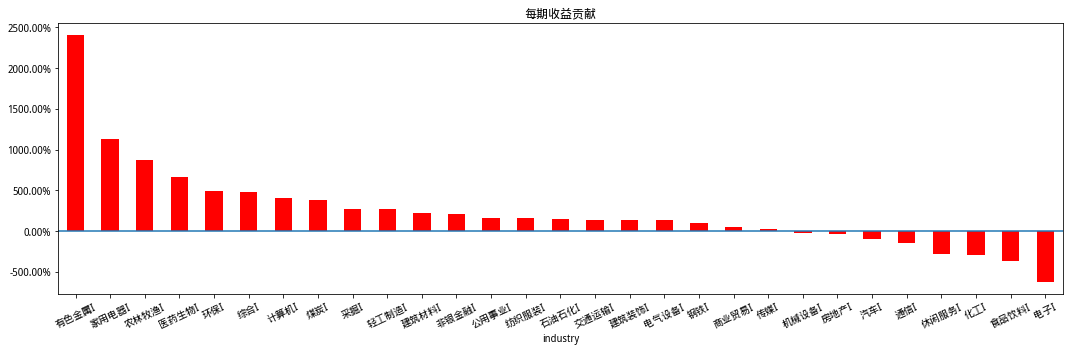

In [83]:
fig,ax = plt.subplots(figsize=(18,5))

ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'{:.2%}'.format(x * 100)))
cross_df.groupby('industry')[1].mean().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5),title='每期收益贡献',ax=ax,rot=25)
plt.axhline(0);

### 3.2.2 RFScore7分与PB20%

In [84]:
#将20%单独分离出来
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 5,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)

Dropped 1.9% entries from factor data (1.9% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [85]:
valuation_factor.head()

1   factor  factor_quantile
date       asset                                          
2018-01-02 000001.XSHE  0.024090   1.1871                1
           000002.XSHE  0.151721   3.0886                3
           000004.XSHE -0.110076  16.2585                5
           000005.XSHE -0.104167   3.6112                3
           000006.XSHE  0.000000   2.6067                2

In [86]:
#给出对应RFScore与PB因子对应层数
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        3.0
           000004.XSHE -0.110076        ...                        5.0
           000005.XSHE -0.104167        ...                        3.0
           000008.XSHE -0.067282        ...                        4.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PB因子(20%),benchmark
年化收益率,16.54%,14.53%,7.15%,-2.36%
累计收益,112.22%,94.83%,40.43%,-11.09%
波动率,24.33%,25.03%,23.59%,20.37%
夏普,74.90%,66.35%,40.73%,-2.04%
最大回撤,-22.82%,-23.70%,-27.06%,-32.93%
IR,17.57%,16.19%,10.00%,nan%
Alpha,19.01%,17.97%,10.65%,nan%
超额收益,18.90%,16.89%,9.51%,0.00%


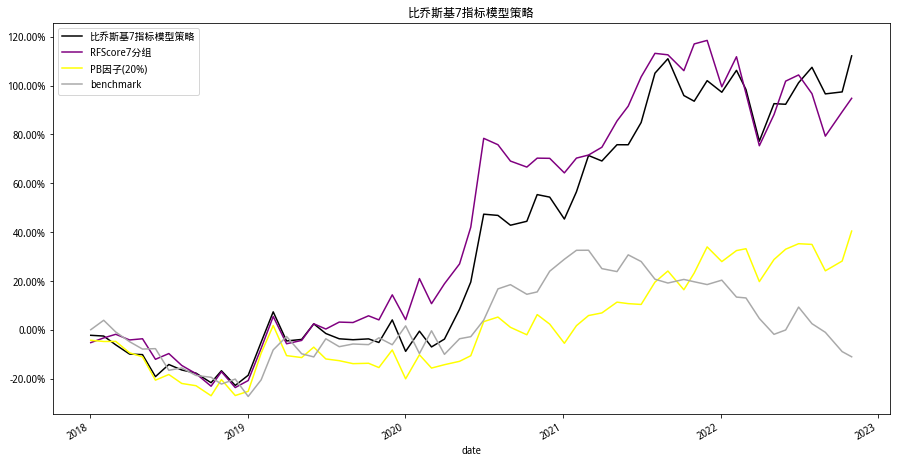

In [87]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(20%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

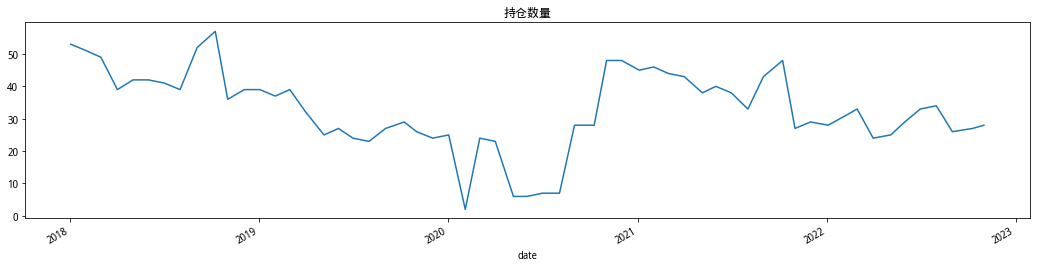

In [88]:
cross_df.groupby(level='date')['factor'].count().plot(title='持仓数量',figsize=(18,4));

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


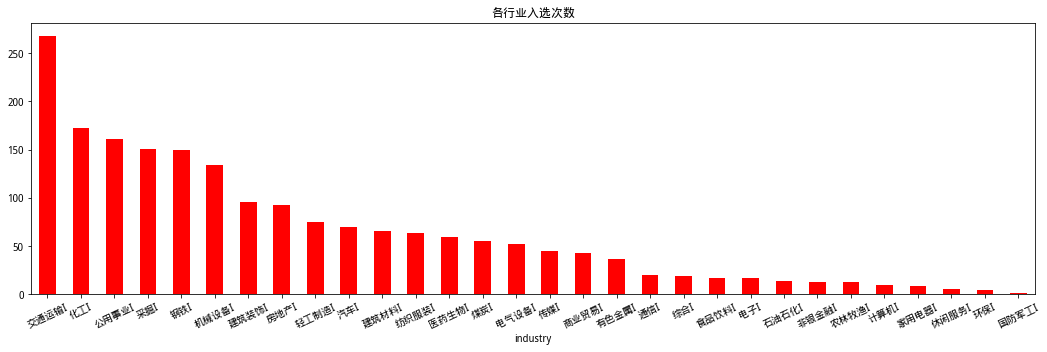

In [89]:
cross_df['industry'] = cross_df.groupby(
    level='date').apply(lambda x: get_stock_ind(
        x.index.get_level_values(1).values.tolist(), x.name, 'sw_l1',
        'industry_name'))
cross_df.groupby('industry')[1].count().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5), title='各行业入选次数',rot=25);

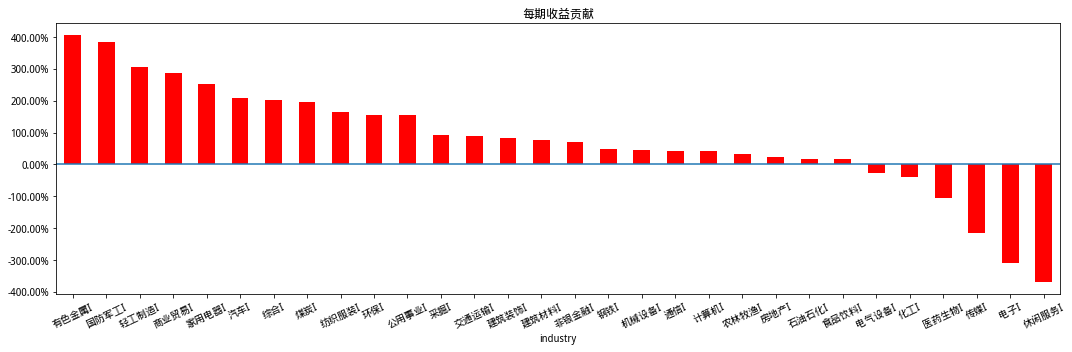

In [90]:
fig,ax = plt.subplots(figsize=(18,5))

ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'{:.2%}'.format(x * 100)))
cross_df.groupby('industry')[1].mean().sort_values(ascending=False).plot.bar(
    color='r', figsize=(18, 5),title='每期收益贡献',ax=ax,rot=25)
plt.axhline(0);

### 3.2.3 RFScore7分与PB后9层

In [147]:
#将20%单独分离出来
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)

Dropped 1.9% entries from factor data (1.9% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [148]:
#给出对应RFScore与PB因子对应层数
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        5.0
           000004.XSHE -0.110076        ...                       10.0
           000005.XSHE -0.104167        ...                        6.0
           000008.XSHE -0.067282        ...                        7.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PB因子(10-20%),benchmark
年化收益率,13.50%,14.53%,8.42%,-2.36%
累计收益,86.37%,94.83%,48.82%,-11.09%
波动率,25.73%,25.03%,24.83%,20.37%
夏普,61.42%,66.35%,44.63%,-2.04%
最大回撤,-24.23%,-23.70%,-29.26%,-32.93%
IR,15.06%,16.19%,11.29%,nan%
Alpha,16.71%,17.97%,12.42%,nan%
超额收益,15.86%,16.89%,10.78%,0.00%


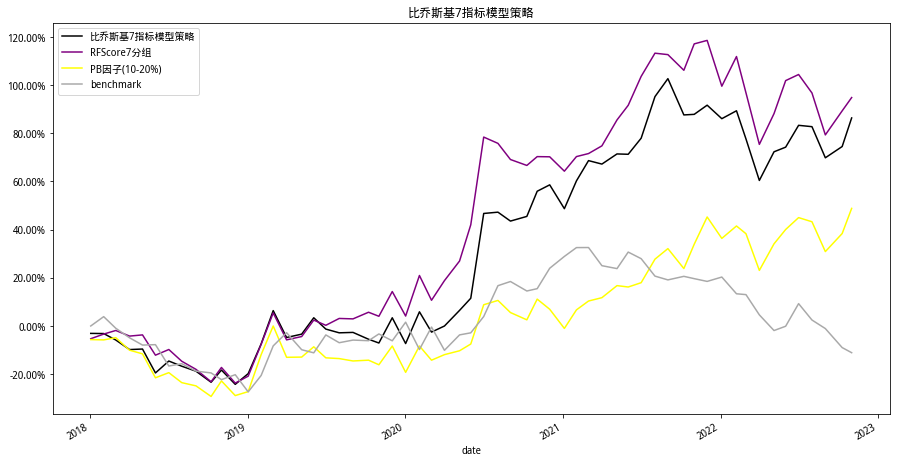

In [149]:
cross_df = df.query('Fundamental_group == 2 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[2],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(10-20%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(20-30%),benchmark
年化收益率,9.73%,14.53%,7.63%,-2.36%
累计收益,57.86%,94.83%,43.57%,-11.09%
波动率,23.51%,25.03%,25.32%,20.37%
夏普,50.96%,66.35%,41.42%,-2.04%
最大回撤,-24.78%,-23.70%,-32.16%,-32.93%
IR,12.48%,16.19%,10.95%,nan%
Alpha,13.31%,17.97%,12.11%,nan%
超额收益,12.09%,16.89%,10.00%,0.00%


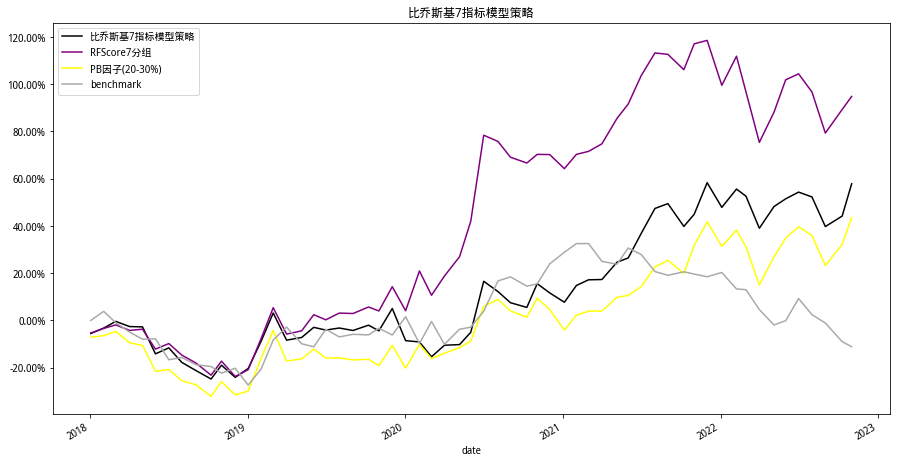

In [150]:
cross_df = df.query('Fundamental_group == 3 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[3],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(20-30%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(30-40%),benchmark
年化收益率,19.69%,14.53%,5.95%,-2.36%
累计收益,141.94%,94.83%,32.88%,-11.09%
波动率,34.09%,25.03%,26.30%,20.37%
夏普,67.68%,66.35%,34.76%,-2.04%
最大回撤,-21.64%,-23.70%,-31.83%,-32.93%
IR,18.55%,16.19%,9.52%,nan%
Alpha,25.02%,17.97%,10.63%,nan%
超额收益,22.05%,16.89%,8.31%,0.00%


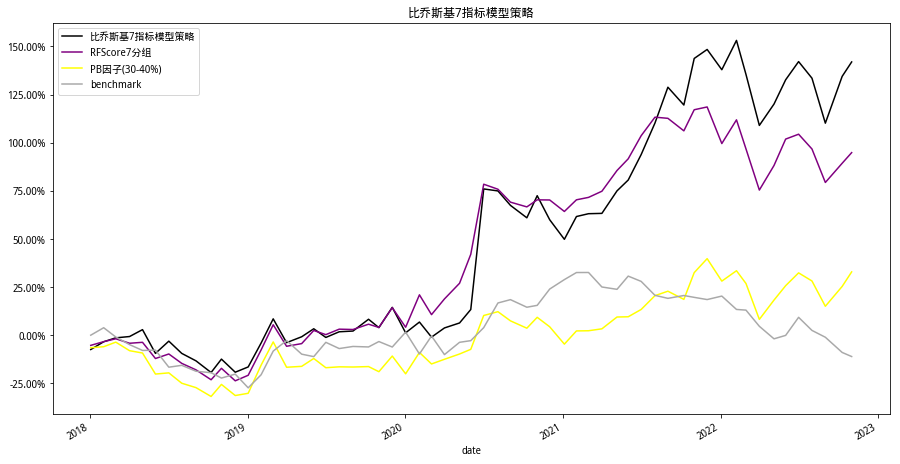

In [152]:
cross_df = df.query('Fundamental_group == 4 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[4],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(30-40%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(40-50%),benchmark
年化收益率,10.57%,14.53%,6.62%,-2.36%
累计收益,63.86%,94.83%,37.04%,-11.09%
波动率,23.11%,25.03%,26.44%,20.37%
夏普,54.90%,66.35%,37.17%,-2.04%
最大回撤,-22.90%,-23.70%,-28.73%,-32.93%
IR,13.41%,16.19%,9.99%,nan%
Alpha,13.91%,17.97%,11.30%,nan%
超额收益,12.93%,16.89%,8.98%,0.00%


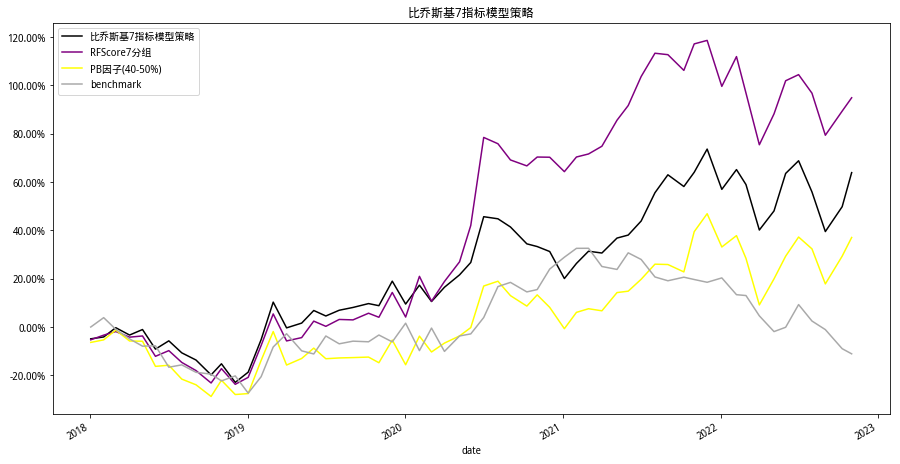

In [153]:
cross_df = df.query('Fundamental_group == 5 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[5],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(40-50%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(50-60%),benchmark
年化收益率,14.69%,14.53%,6.26%,0.02%
累计收益,96.21%,94.83%,34.81%,0.09%
波动率,25.10%,25.03%,27.04%,19.88%
夏普,67.81%,66.35%,35.61%,9.71%
最大回撤,-26.87%,-23.70%,-30.44%,-32.93%
IR,15.81%,12.14%,5.89%,nan%
Alpha,18.55%,14.81%,8.51%,nan%
超额收益,14.67%,14.51%,6.24%,0.00%


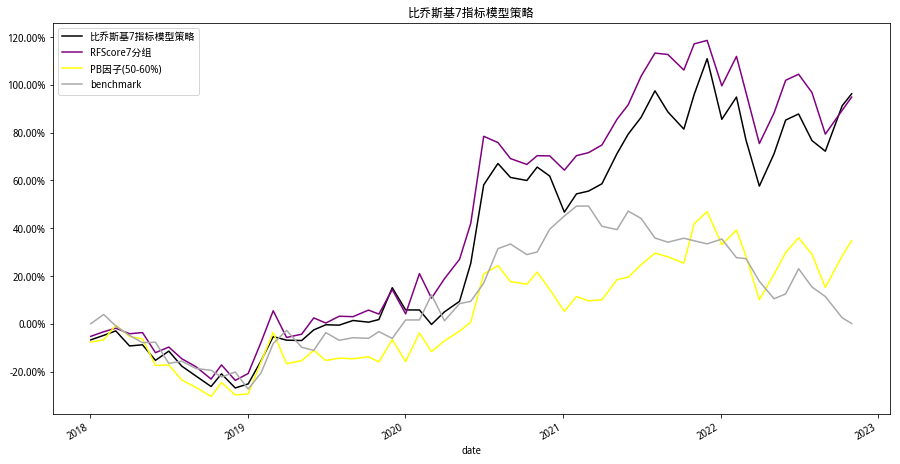

In [162]:
cross_df = df.query('Fundamental_group == 6 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[6],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(50-60%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(60-70%),benchmark
年化收益率,10.19%,14.53%,4.29%,-2.36%
累计收益,61.12%,94.83%,22.94%,-11.09%
波动率,26.60%,25.03%,26.94%,20.37%
夏普,49.22%,66.35%,28.69%,-2.04%
最大回撤,-25.95%,-23.70%,-30.90%,-32.93%
IR,11.88%,16.19%,8.61%,nan%
Alpha,13.95%,17.97%,9.75%,nan%
超额收益,12.55%,16.89%,6.65%,0.00%


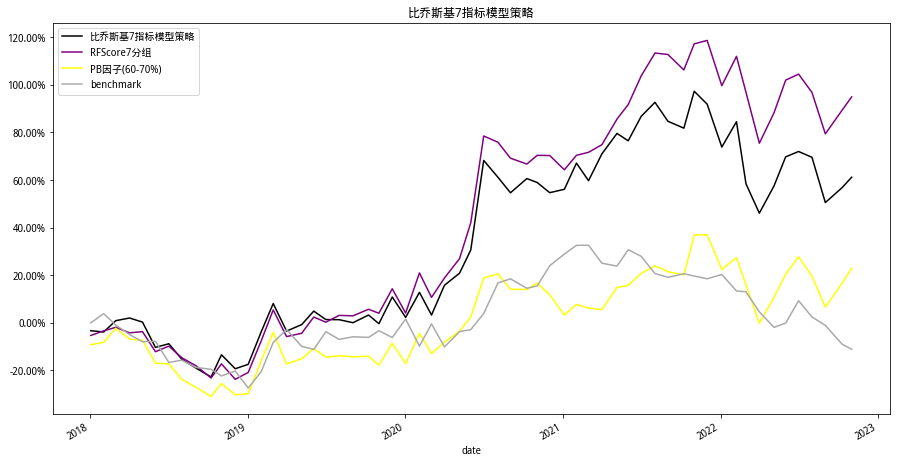

In [161]:
cross_df = df.query('Fundamental_group == 7 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[7],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(60-70%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(70-80%),benchmark
年化收益率,6.13%,14.53%,0.63%,-2.36%
累计收益,33.96%,94.83%,3.14%,-11.09%
波动率,27.51%,25.03%,27.76%,20.37%
夏普,35.18%,66.35%,15.85%,-2.04%
最大回撤,-32.47%,-23.70%,-33.91%,-32.93%
IR,10.47%,16.19%,5.62%,nan%
Alpha,11.85%,17.97%,6.39%,nan%
超额收益,8.49%,16.89%,2.99%,0.00%


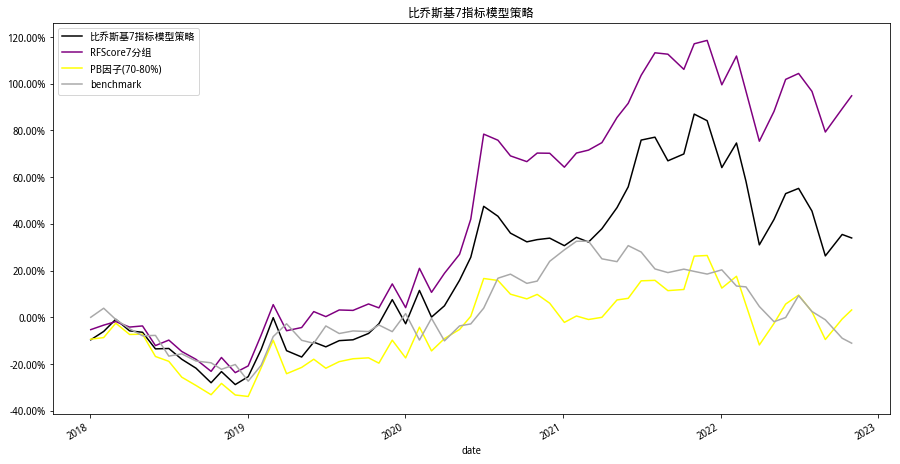

In [160]:
cross_df = df.query('Fundamental_group == 8 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[8],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(70-80%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(80-90%),benchmark
年化收益率,14.52%,14.53%,-0.43%,-2.36%
累计收益,94.78%,94.83%,-2.09%,-11.09%
波动率,32.52%,25.03%,27.89%,20.37%
夏普,56.79%,66.35%,12.05%,-2.04%
最大回撤,-26.80%,-23.70%,-33.65%,-32.93%
IR,15.28%,16.19%,4.78%,nan%
Alpha,19.77%,17.97%,5.39%,nan%
超额收益,16.88%,16.89%,1.93%,0.00%


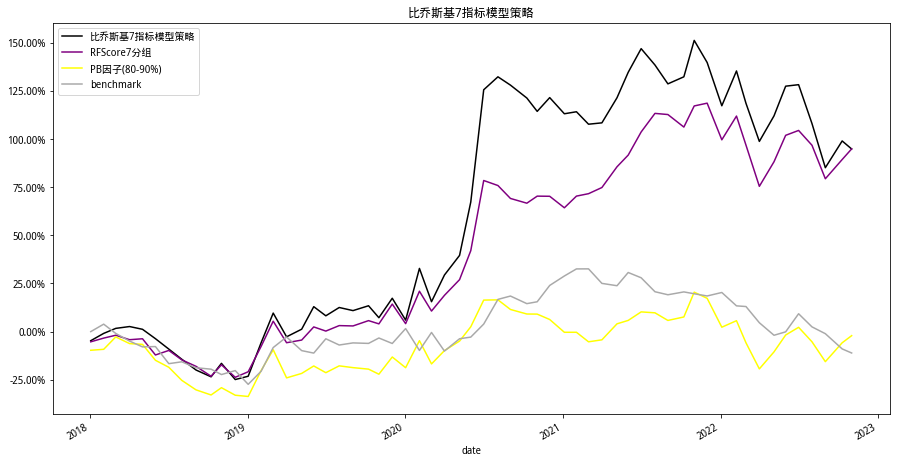

In [158]:
cross_df = df.query('Fundamental_group == 9 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[9],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(80-90%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

,比乔斯基7指标模型策略,RFScore7分组,PB因子(90-100%),benchmark
年化收益率,10.12%,14.53%,-2.14%,-2.36%
累计收益,60.64%,94.83%,-10.09%,-11.09%
波动率,29.88%,25.03%,26.63%,20.37%
夏普,46.59%,66.35%,4.84%,-2.04%
最大回撤,-33.36%,-23.70%,-37.78%,-32.93%
IR,12.85%,16.19%,3.12%,nan%
Alpha,15.82%,17.97%,3.22%,nan%
超额收益,12.48%,16.89%,0.22%,0.00%


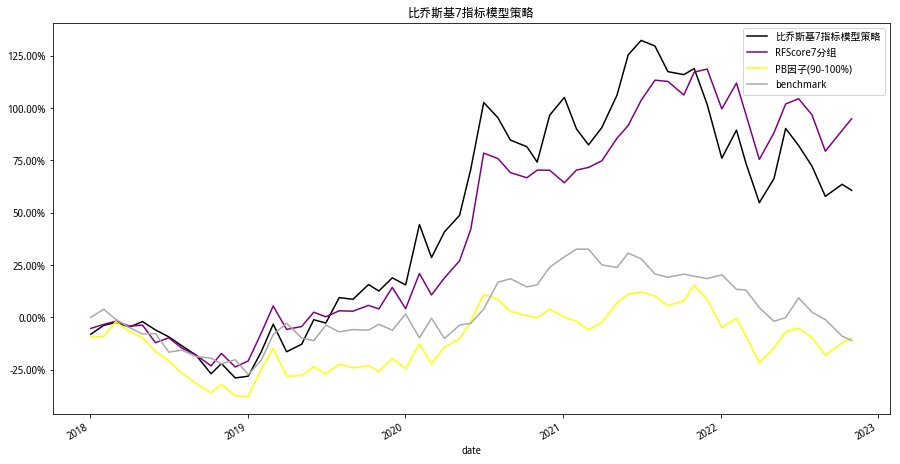

In [159]:
cross_df = df.query('Fundamental_group == 10 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[10],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PB因子(90-100%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

# 4 改变基本面因子：PE,DP,PS,PCF

## 4.1PE，无效

In [166]:
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 10,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)

Dropped 1.8% entries from factor data (1.8% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [167]:
#给出对应RFScore与PB因子对应层数
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        1.0
           000004.XSHE -0.110076        ...                        9.0
           000005.XSHE -0.104167        ...                        NaN
           000008.XSHE -0.067282        ...                        7.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PE因子(10%),benchmark
年化收益率,1.30%,14.53%,2.03%,0.02%
累计收益,6.53%,94.83%,10.41%,0.09%
波动率,22.44%,25.03%,20.88%,19.88%
夏普,16.98%,66.35%,19.79%,9.71%
最大回撤,-26.95%,-23.70%,-28.49%,-32.93%
IR,1.40%,12.14%,-0.23%,nan%
Alpha,3.53%,14.81%,1.72%,nan%
超额收益,1.28%,14.51%,2.02%,0.00%


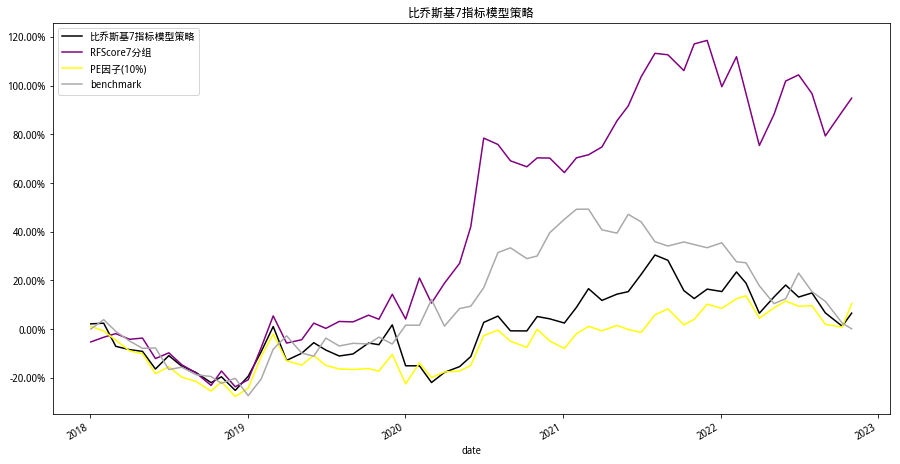

In [168]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PE因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

In [169]:
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 5,
                                                           periods=(1,))
valuation_ret = pd.pivot_table(valuation_factor.reset_index(),index='date',columns='factor_quantile',values=1)

Dropped 1.8% entries from factor data (1.8% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [170]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        1.0
           000002.XSHE  0.151721        ...                        1.0
           000004.XSHE -0.110076        ...                        5.0
           000005.XSHE -0.104167        ...                        NaN
           000008.XSHE -0.067282        ...                        4.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PE因子(20%),benchmark
年化收益率,4.59%,14.53%,3.62%,-2.36%
累计收益,24.71%,94.83%,19.13%,-11.09%
波动率,20.75%,25.03%,21.55%,20.37%
夏普,31.81%,66.35%,26.98%,-2.04%
最大回撤,-26.00%,-23.70%,-29.37%,-32.93%
IR,6.95%,16.19%,6.30%,nan%
Alpha,6.84%,17.97%,6.24%,nan%
超额收益,6.96%,16.89%,5.99%,0.00%


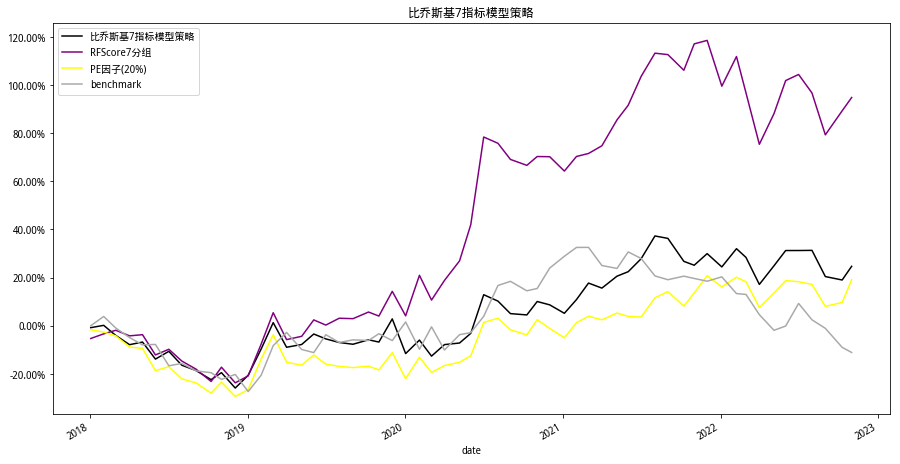

In [171]:
cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PE因子(20%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

## 4.2 DP因子：结合效果稍好，但比RFScore7分效果差

In [175]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        8.0
           000002.XSHE  0.151721        ...                       10.0
           000004.XSHE -0.110076        ...                        NaN
           000005.XSHE -0.104167        ...                        NaN
           000008.XSHE -0.067282        ...                        1.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,DP因子(10%),benchmark
年化收益率,11.11%,14.53%,-1.71%,-2.36%
累计收益,67.85%,94.83%,-8.11%,-11.09%
波动率,33.14%,25.03%,29.04%,20.37%
夏普,47.33%,66.35%,8.16%,-2.04%
最大回撤,-29.68%,-23.70%,-40.33%,-32.93%
IR,13.30%,16.19%,4.11%,nan%
Alpha,17.91%,17.97%,4.66%,nan%
超额收益,13.47%,16.89%,0.66%,0.00%


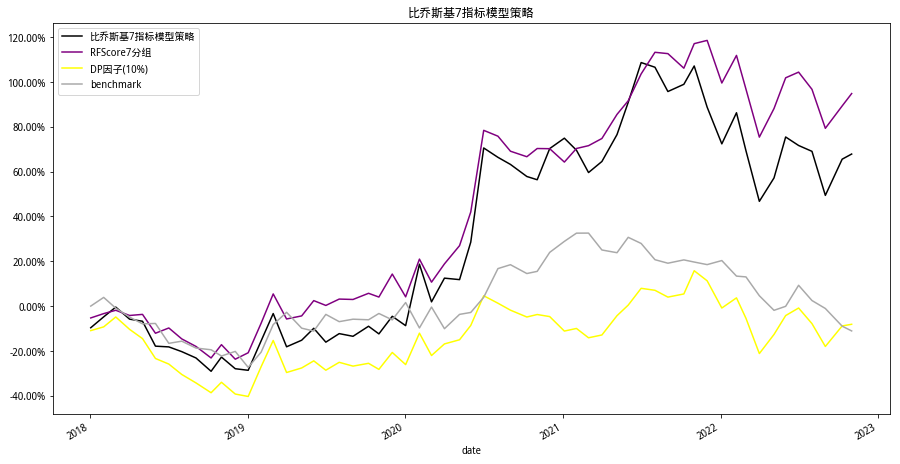

In [176]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','DP因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

In [177]:
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 5,
                                                           periods=(1,))

Dropped 2.0% entries from factor data (2.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [178]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        4.0
           000002.XSHE  0.151721        ...                        5.0
           000004.XSHE -0.110076        ...                        NaN
           000005.XSHE -0.104167        ...                        NaN
           000008.XSHE -0.067282        ...                        1.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,DP因子(20%),benchmark
年化收益率,12.84%,14.53%,-1.71%,-2.36%
累计收益,81.14%,94.83%,-8.11%,-11.09%
波动率,31.57%,25.03%,29.04%,20.37%
夏普,53.45%,66.35%,8.16%,-2.04%
最大回撤,-30.30%,-23.70%,-40.33%,-32.93%
IR,14.74%,16.19%,4.11%,nan%
Alpha,18.84%,17.97%,4.66%,nan%
超额收益,15.21%,16.89%,0.66%,0.00%


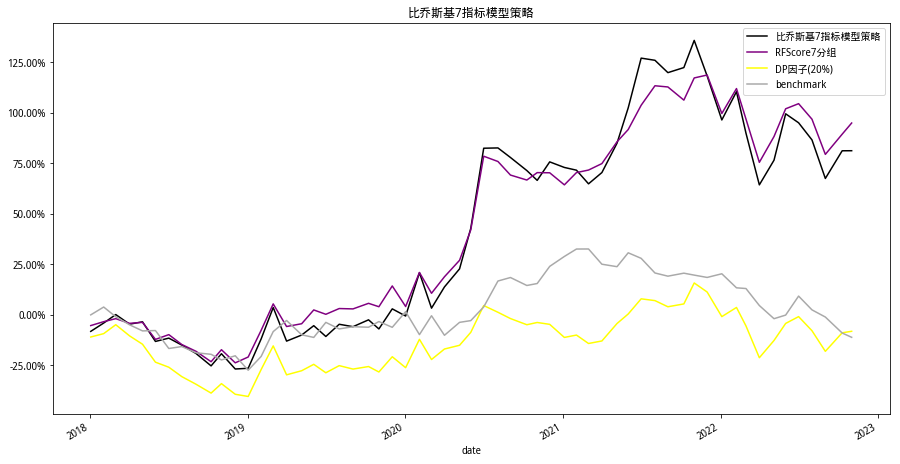

In [179]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','DP因子(20%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

## 4.3 PS因子：无效

In [183]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        3.0
           000002.XSHE  0.151721        ...                        2.0
           000004.XSHE -0.110076        ...                       10.0
           000005.XSHE -0.104167        ...                        9.0
           000008.XSHE -0.067282        ...                       10.0

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PS因子(10%),benchmark
年化收益率,6.85%,14.53%,7.81%,0.02%
累计收益,38.51%,94.83%,44.72%,0.09%
波动率,23.44%,25.03%,23.09%,19.88%
夏普,40.14%,66.35%,43.80%,9.71%
最大回撤,-32.16%,-23.70%,-28.44%,-32.93%
IR,6.94%,12.14%,6.43%,nan%
Alpha,9.32%,14.81%,8.71%,nan%
超额收益,6.83%,14.51%,7.79%,0.00%


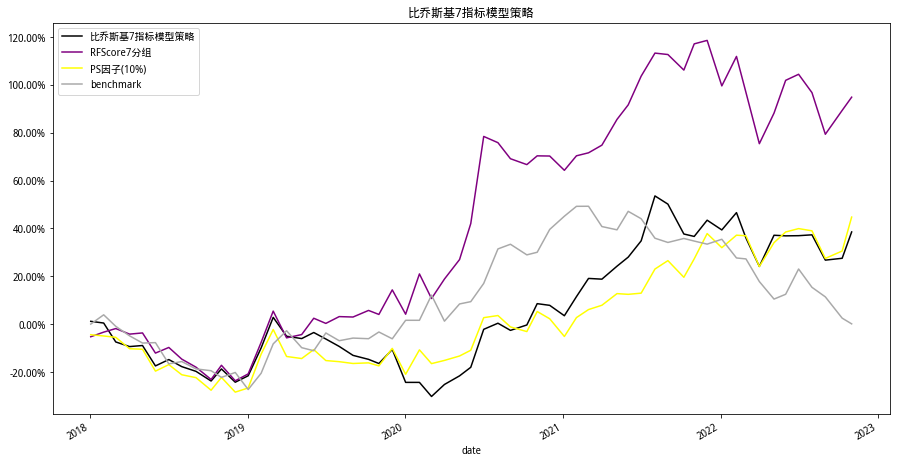

In [184]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PS因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

## 4.4 PCF因子：结合效果一般，依然比RFScore7分差

In [189]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        NaN
           000002.XSHE  0.151721        ...                        3.0
           000004.XSHE -0.110076        ...                        NaN
           000005.XSHE -0.104167        ...                        NaN
           000008.XSHE -0.067282        ...                        NaN

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PS因子(10%),benchmark
年化收益率,7.23%,14.53%,4.94%,0.02%
累计收益,40.92%,94.83%,26.77%,0.09%
波动率,29.34%,25.03%,23.37%,19.88%
夏普,37.57%,66.35%,32.06%,9.71%
最大回撤,-23.93%,-23.70%,-27.26%,-32.93%
IR,8.30%,12.14%,3.81%,nan%
Alpha,12.39%,14.81%,5.97%,nan%
超额收益,7.21%,14.51%,4.92%,0.00%


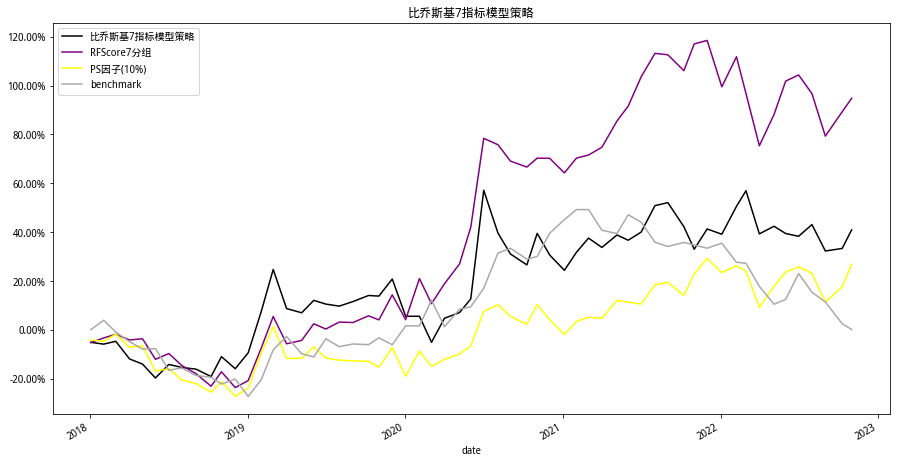

In [190]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PCF因子(10%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')

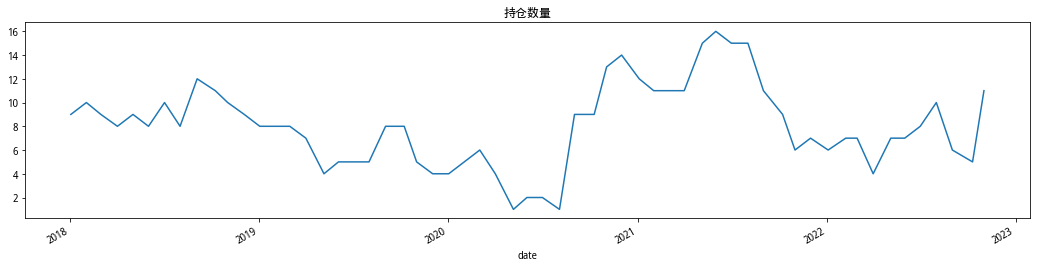

In [191]:
cross_df.groupby(level='date')['factor'].count().plot(title='持仓数量',figsize=(18,4));

In [192]:
pivot_valuation.index = pd.to_datetime(pivot_valuation.index)
valuation_ser = pivot_valuation.stack()
valuation_ser.index.names = ['date','asset']
valuation_factor = al.utils.get_clean_factor_and_forward_returns(valuation_ser,
                                                           pivot_price,
                                                           quantiles = 5,
                                                           periods=(1,))

Dropped 2.0% entries from factor data (2.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


In [193]:
df = fscore_factor_data.copy()
df['Fundamental_group'] = valuation_factor['factor_quantile']
df.head()

1        ...          Fundamental_group
date       asset                        ...                           
2018-01-02 000001.XSHE  0.024090        ...                        NaN
           000002.XSHE  0.151721        ...                        2.0
           000004.XSHE -0.110076        ...                        NaN
           000005.XSHE -0.104167        ...                        NaN
           000008.XSHE -0.067282        ...                        NaN

[5 rows x 4 columns]

,比乔斯基7指标模型策略,RFScore7分组,PCF因子(20%),benchmark
年化收益率,11.21%,14.53%,4.94%,-2.36%
累计收益,68.62%,94.83%,26.77%,-11.09%
波动率,25.13%,25.03%,23.37%,20.37%
夏普,54.46%,66.35%,32.06%,-2.04%
最大回撤,-21.89%,-23.70%,-27.26%,-32.93%
IR,13.60%,16.19%,8.01%,nan%
Alpha,15.05%,17.97%,8.46%,nan%
超额收益,13.57%,16.89%,7.30%,0.00%


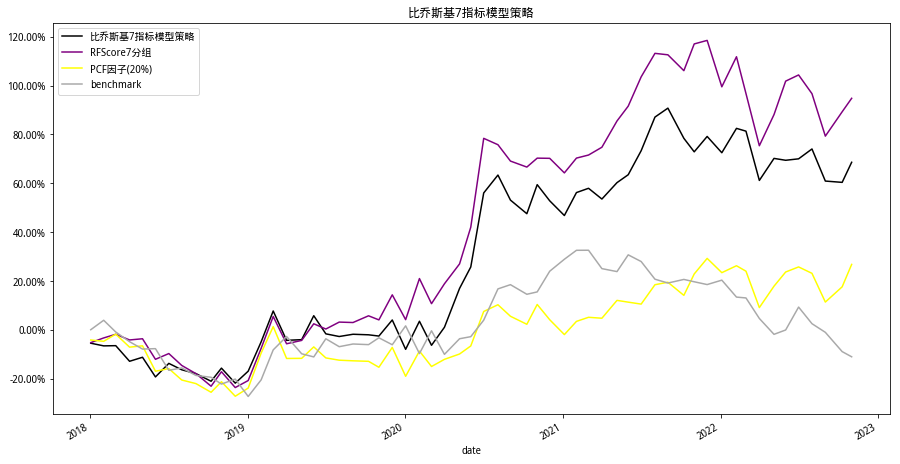

In [194]:

cross_df = df.query('Fundamental_group == 1 and factor_quantile == 7')
cross_ret = pd.pivot_table(cross_df.reset_index(),index='date',columns='factor_quantile',values=1)
fih,ax = plt.subplots(figsize=(15,8))
ax.set_title('比乔斯基7指标模型策略')

all_ret = pd.concat((cross_ret[7],fscore_factor_ret[7],valuation_ret[1],benchmark_ret.reindex(cross_ret.index)),axis=1)
all_ret.columns = ['比乔斯基7指标模型策略','RFScore7分组','PCF因子(20%)','benchmark']


ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x,pos:'%.2f%%'%(x*100)))
ep.cum_returns(all_ret).plot(ax=ax,color=color_map[:3] + ['darkgray'])
ax.legend();
Strategy_performance(all_ret,'monthly').style.format('{:.2%}')